# MBERE ML: End-to-End ML Pipeline (Addis Ababa Road Traffic Accident Severity Risk Prediction)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Terrymanzi/MBERE_ML/blob/main/ml/notebooks/ml_pipeline_end_to_end.ipynb)

This notebook runs the **actual `ml/` package** from the MBERE_ML repository end to end on Google Colab.

**Dataset:** Addis Ababa Road Traffic Accident data. **Task:** predict accident severity (`Slight` / `Serious` / `Fatal`) as an interpretable, pre-accident driver-risk proxy.

## What's new in Experiment 4

Experiment 3 trained five models (`baseline`, `random_forest`, `xgboost`, `random_forest_tuned`,
`xgboost_tuned`) and got a reviewer critique of the modelling choices (attached separately).
The core diagnosis in that critique was: **this dataset's models are not limited by
hyperparameters — they are limited by extreme class imbalance** (Slight 84.6% / Serious 14.1% /
Fatal 1.3% of accidents) and by how little information 127-158 Fatal-injury rows carry. Section
12.5 below is **entirely new** and works through that critique's suggestions **systematically and
honestly**, with every number generated by actually running the code against the real Addis Ababa
data already in this repo — not estimated or assumed. Two new suggestions turned out to help
(swapping the resampler, and confirming feature selection was already correct); several plausible
suggestions were tested and **did not** hold up on this dataset, and that is reported too, because
an honest negative result is still evidence. Nothing in Sections 1-11 or 12.1-12.4 was touched —
Experiment 4 only *adds* Section 12.5 onward and threads two new models through the existing
comparison/evaluation/SHAP sections alongside the original five.

**Headline result:** swapping the in-pipeline resampler from `SMOTE` to `SMOTEENN` — with
**no other change** to Random Forest's Section-12.2 default hyperparameters — beats every model
from Experiment 3 on the held-out test set. The gain is real but modest (test `f1_macro` 0.346 ->
0.346, +0.001), which itself matches the reviewer critique's own framing: with only 31 Fatal-injury
rows in the test set, there just isn't much room left to extract without more data.

**Pipeline stages covered:**

1. Environment setup (clone + install)
2. Dataset configuration (`ml/configs/addis.yaml`)
3. Raw data exploration
4. Data cleaning (leakage-safe, deterministic)
5. Feature engineering (interpretable derived features)
6. Stratified train/test split
7. Feature selection (mutual information, train-only)
8. Encoding (ordinal + one-hot, fit on train only)
9. Authoritative preprocessing run (persists artifacts)
10. Model architecture (rule-based baseline, Random Forest, XGBoost)
11. SMOTE-in-pipeline demonstration (leak-free class rebalancing)
12. Model training (shared stratified CV harness, out-of-fold metrics) + **12.5 Experiment 4:
    reviewer-feedback-driven improvements (resampler search, ratio search, feature-set ablation,
    interaction-feature ablation, CatBoost benchmark, expanded XGBoost search, threshold tuning)**
13. Cross-validation metrics comparison (now 7 models) + per-class diagnostics
14. Held-out test set evaluation (confusion matrices, ROC curves)
15. Test metrics comparison & model selection (now 7 models) + per-class diagnostics
16. Explainability (SHAP: global summary + local waterfall)
17. Saved artifacts & reproducibility
18. Optional synthetic (Rwandan) data sanity check
19. Downloading artifacts from Colab (for inference only)

## 1. Environment setup

Clones the my capstone repo and installs the pinned package versions from `ml/requirements.txt`, so the notebook environment matches the project's `.venv` exactly.

In [25]:
import os

REPO_URL = "https://github.com/Terrymanzi/MBERE_ML.git"
REPO_DIR = "/content/MBERE_ML"

if not os.path.isdir(REPO_DIR):
    !git clone --quiet {REPO_URL} {REPO_DIR}
else:
    print("Repo already present — pulling latest changes.")
    !git -C {REPO_DIR} pull --quiet

os.chdir(REPO_DIR)
print("Working directory:", os.getcwd())

# Install project requirements first. This might install conflicting versions initially.
!pip install -q -r ml/requirements.txt

# --- Start of updated fix for dependency conflicts and ImportError ---

# Downgrade pandas to be compatible with google-colab (requires pandas==2.2.2).
!pip install -q pandas==2.2.2

# Downgrade numba to be compatible with pytensor (requires numba<=0.65.1).
!pip install -q numba==0.65.1

# Force-reinstall numpy, scipy, and scikit-learn to known stable and compatible versions for Python 3.12.
# numpy 2.0.0 is the first version with full Python 3.12 support, addressing the ImportError.
# scipy 1.13.0 satisfies many packages requiring >=1.13.
# scikit-learn 1.5.0 satisfies imbalanced-learn and other packages requiring >=1.4.
!pip install -q --force-reinstall numpy==2.0.0 scipy==1.13.0 scikit-learn==1.5.0

# --- Experiment 4 additions (additive only -- nothing above this line changed) ---
# catboost: native-categorical benchmark model (Section 12.5.6)
# optuna:   smarter hyperparameter search than grid search (Section 12.5.8)
!pip install -q catboost optuna

import sys

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import matplotlib
import numpy as np
import pandas as pd
import sklearn

print("python  ", sys.version.split()[0])
print("pandas  ", pd.__version__)
print("numpy   ", np.__version__)
print("sklearn ", sklearn.__version__)

import xgboost
import imblearn
import shap
print("xgboost ", xgboost.__version__)
print("imblearn", imblearn.__version__)
print("shap    ", shap.__version__)

import catboost
import optuna
print("catboost", catboost.__version__)
print("optuna  ", optuna.__version__)

!git -C {REPO_DIR} rev-parse --short HEAD


Repo already present — pulling latest changes.
Working directory: /content/MBERE_ML
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.2 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.0 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.0 which is incompatible.
access 1.1.10.post3 requires scipy>=1.14.1, but you have scipy 1.13.0 which is incompatible.
hdbscan 

## 2. Notebook plotting style

A small, fixed color system so every chart in this notebook reads consistently:
- **Categorical** (model identity: `baseline` / `random_forest` / `xgboost` / `random_forest_tuned` / `xgboost_tuned` / `random_forest_resampled` / `xgboost_resampled`) — fixed hue order, never re-cycled. The `_tuned` variants (Section 12.4) get a darker shade of their ordinary counterpart's color; the new Experiment-4 `_resampled` variants (Section 12.5) get a third, even deeper shade of the same family, so the three "generations" of each model are visually traceable.
- **Ordinal** (severity: Slight → Serious → Fatal) — a single blue ramp, light → dark, since severity is an *ordered* magnitude, not an unordered category.

In [26]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Fixed categorical order (never re-cycled across charts): baseline, then the
# ordinary (Section 12.2/12.3) models, then their tuned (Section 12.4)
# counterparts, then the new Experiment-4 resampled variants (Section 12.5).
MODEL_COLORS = {
    "baseline": "#2a78d6",                  # blue
    "random_forest": "#1baf7a",             # aqua
    "xgboost": "#eda100",                   # yellow
    "random_forest_tuned": "#0f7a54",       # darker aqua/green (tuned RF)
    "xgboost_tuned": "#c77900",             # darker amber (tuned XGBoost)
    "random_forest_resampled": "#0a4a34",   # deepest aqua/green (Experiment 4 RF)
    "xgboost_resampled": "#8f5400",         # deepest amber (Experiment 4 XGBoost)
}
MODEL_ORDER = [
    "baseline", "random_forest", "xgboost", "random_forest_tuned", "xgboost_tuned",
    "random_forest_resampled", "xgboost_resampled",
]

# Ordinal severity ramp (light -> dark blue), start no lighter than step 250
SEVERITY_COLORS = ["#86b6ef", "#2a78d6", "#104281"]  # Slight, Serious, Fatal

# Categorical pair for before/after or train/test comparisons
PAIR_COLORS = ["#2a78d6", "#1baf7a"]

def bar_with_labels(ax, x, heights, colors, fmt="{:.3f}"):
    bars = ax.bar(x, heights, color=colors, width=0.6)
    for rect, h in zip(bars, heights):
        ax.annotate(fmt.format(h), (rect.get_x() + rect.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=9, color="#52514e")
    return bars

def grouped_bar_by_model(ax, metrics_to_plot, summary_df, model_order=MODEL_ORDER, colors=MODEL_COLORS):
    """Grouped bar chart, one group per metric, one bar per model -- scales to any
    number of models in `model_order` (used for both the CV and test comparisons)."""
    n_models = len(model_order)
    width = 0.8 / n_models
    x = np.arange(len(metrics_to_plot))
    offset0 = -(n_models - 1) / 2
    for i, model in enumerate(model_order):
        values = [summary_df.loc[model, m] for m in metrics_to_plot]
        ax.bar(x + (offset0 + i) * width, values, width, label=model, color=colors[model])
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_to_plot)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, fontsize=9, ncol=min(n_models, 3))
    return ax

def fmt4(x):
    return f"{x:.4f}" if x is not None else "n/a"

def print_per_class(model_name, metrics):
    """Experiment 4 addition (reviewer feedback item #13): per-class precision/
    recall/F1/support in one line per class, instead of only the macro average.
    With Fatal at 1.3% of rows, macro F1 alone hides *which* class is driving a
    good or bad score -- this makes it explicit every time metrics are printed."""
    print(f"  per-class diagnostics ({model_name}):")
    for cls in metrics["labels"]:
        pc = metrics["per_class"][cls]
        print(f"    {cls:16s} precision={pc['precision']:.4f}  recall={pc['recall']:.4f}  "
              f"f1={pc['f1']:.4f}  support={pc['support']}")

print("Plotting style ready.")


Plotting style ready.


## 3. Load the dataset configuration

Everything downstream — column names, cleaning rules, engineered features, encoding strategy, split, feature-selection threshold — is driven by `ml/configs/addis.yaml`. Nothing here is hardcoded twice; the notebook reads the same config the pipeline scripts do.

In [27]:
from ml.utils.config import load_config
from ml.utils.paths import PROJECT_ROOT

config = load_config(PROJECT_ROOT / "ml" / "configs" / "addis.yaml")

print(f"dataset        : {config.name} ({config.kind})")
print(f"target column  : {config.target.column}")
print(f"classes        : {config.target.classes}")
print(f"raw path       : {config.paths.raw}")
print(f"test_size      : {config.split.test_size}  (stratified={config.split.stratify})")
print(f"k_folds        : {config.split.k_folds}")
print(f"feature_select : {config.feature_selection.method} @ threshold={config.feature_selection.threshold}")
print(f"baseline kind  : {config.baseline.kind}")
print(f"n features     : {len(config.features.all)} -> {config.features.all}")


dataset        : addis (multiclass)
target column  : Accident_severity
classes        : ['Slight Injury', 'Serious Injury', 'Fatal Injury']
raw path       : /content/MBERE_ML/data/raw/RTA Dataset.csv
test_size      : 0.2  (stratified=True)
k_folds        : 5
feature_select : mutual_info @ threshold=0.0003
baseline kind  : rule_based
n features     : 13 -> ['driver_age_band', 'driver_experience', 'time_of_day', 'driver_education', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_sex', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']


## 4. Raw data exploration

Before any cleaning: shape, dtypes, and the raw (uncleaned) target distribution — including the inconsistent `"Fatal injury"` casing that `clean()` will normalize.

raw shape: (12316, 32)
Time                           object
Day_of_week                    object
Age_band_of_driver             object
Sex_of_driver                  object
Educational_level              object
Vehicle_driver_relation        object
Driving_experience             object
Type_of_vehicle                object
Owner_of_vehicle               object
Service_year_of_vehicle        object
Defect_of_vehicle              object
Area_accident_occured          object
Lanes_or_Medians               object
Road_allignment                object
Types_of_Junction              object
Road_surface_type              object
Road_surface_conditions        object
Light_conditions               object
Weather_conditions             object
Type_of_collision              object
Number_of_vehicles_involved     int64
Number_of_casualties            int64
Vehicle_movement               object
Casualty_class                 object
Sex_of_casualty                object
Age_band_of_casualty       

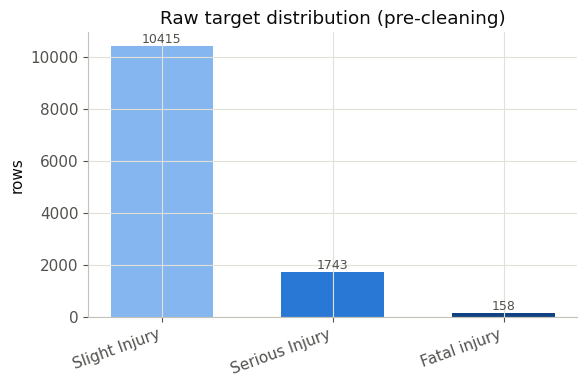

In [28]:
from ml.preprocessing.load import load_raw

raw_df = load_raw(config)
print("raw shape:", raw_df.shape)
raw_df.head()

print(raw_df.dtypes)
print()
print("Raw target value counts (before cleaning / label normalization):")
print(raw_df[config.target.column].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(6, 4))
counts = raw_df[config.target.column].value_counts(dropna=False)
bar_with_labels(ax, range(len(counts)), counts.values,
                colors=[SEVERITY_COLORS[i % 3] for i in range(len(counts))], fmt="{:.0f}")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=20, ha="right")
ax.set_ylabel("rows")
ax.set_title("Raw target distribution (pre-cleaning)")
fig.tight_layout()
plt.show()


## 5. Data cleaning

`ml.preprocessing.clean.clean()` is deterministic and row-wise (no statistic is learned from the data), so it is safe to run on the full dataset before splitting:

- drops **leakage columns** (post-accident casualty/outcome fields — `Casualty_severity` is effectively a target proxy)
- derives `hour_of_day` from the raw `Time` column, then drops the raw timestamp
- trims strings and maps missing tokens (`""`, `"na"`, `"nan"`, `"unknown"`) to a constant fill value (`"Unknown"`) — parameter-free, so leakage-safe
- canonicalizes target labels (e.g. `"Fatal injury"` → `"Fatal Injury"`) and drops rows with an invalid/missing target or unparseable time

In [29]:
from ml.preprocessing.clean import clean

n_before = len(raw_df)
cleaned_df = clean(raw_df, config)
n_after = len(cleaned_df)

print(f"rows: {n_before} -> {n_after}  (dropped {n_before - n_after})")
print(f"columns after cleaning: {cleaned_df.shape[1]}")
cleaned_df.head()

print("Any missing values left in non-target columns?")
non_target = cleaned_df.drop(columns=[config.target.column])
print(non_target.isna().sum().sum(), "missing cells (expected 0 -- constant-filled)")
print()
print("Cleaned target distribution:")
print(cleaned_df[config.target.column].value_counts())


[INFO] mbere-ml: clean: rows 12316 -> 12316 (dropped 0); cols=25


rows: 12316 -> 12316  (dropped 0)
columns after cleaning: 25
Any missing values left in non-target columns?
0 missing cells (expected 0 -- constant-filled)

Cleaned target distribution:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal Injury        158
Name: count, dtype: Int64


## 6. Feature engineering

`ml.features.feature_engineering.engineer_features()` derives the proposal's interpretable features from the cleaned columns — still deterministic and row-wise, so still safe before the split:

- 1:1 renames (e.g. `Age_band_of_driver` → `driver_age_band`)
- `time_of_day` bucket derived from `hour_of_day` (Night / Morning / Afternoon / Evening)
- `vehicle_type` grouping from the 17 raw vehicle labels via ordered keyword rules (motorcycle kept first-class, not folded into "Other")

engineered shape: (12316, 14)
engineered feature columns: ['driver_age_band', 'driver_experience', 'time_of_day', 'driver_education', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_sex', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']


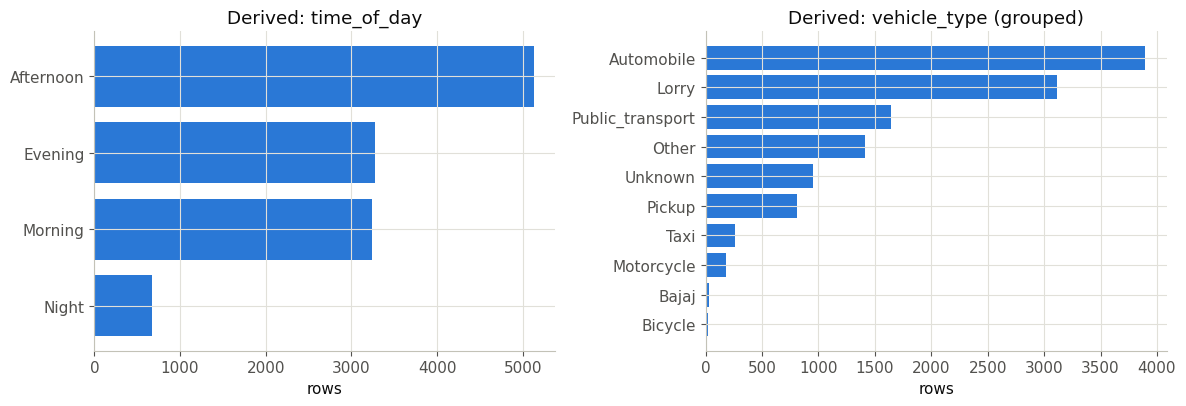

In [30]:
from ml.features.feature_engineering import engineer_features

engineered_df = engineer_features(cleaned_df, config)
print("engineered shape:", engineered_df.shape)
print("engineered feature columns:", [c for c in engineered_df.columns if c != config.target.column])
engineered_df.head()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, col, title in zip(
    axes, ["time_of_day", "vehicle_type"],
    ["Derived: time_of_day", "Derived: vehicle_type (grouped)"],
):
    counts = engineered_df[col].value_counts()
    ax.barh(counts.index[::-1], counts.values[::-1], color="#2a78d6")
    ax.set_title(title)
    ax.set_xlabel("rows")

fig.tight_layout()
plt.show()


## 7. Train/test split (stratified)

`ml.preprocessing.split.make_split()` returns reproducible, **stratified** positional indices — this preserves class proportions (especially the rare `Fatal` class) in both folds. The split happens *before* any fitting (encoder, feature selection), so nothing downstream ever sees test data during fitting.

train: 9852 rows   test: 2464 rows (20.0% test)


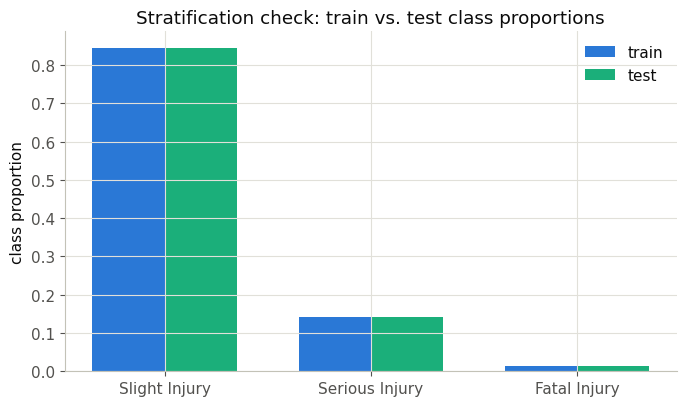

In [31]:
from ml.preprocessing.split import make_split

train_idx, test_idx = make_split(engineered_df, config)
train_df = engineered_df.iloc[train_idx].reset_index(drop=True)
test_df = engineered_df.iloc[test_idx].reset_index(drop=True)

print(f"train: {len(train_df)} rows   test: {len(test_df)} rows "
      f"({len(test_df) / len(engineered_df):.1%} test)")

train_props = train_df[config.target.column].value_counts(normalize=True).reindex(config.target.classes)
test_props = test_df[config.target.column].value_counts(normalize=True).reindex(config.target.classes)

x = np.arange(len(config.target.classes))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(x - width / 2, train_props.values, width, label="train", color=PAIR_COLORS[0])
ax.bar(x + width / 2, test_props.values, width, label="test", color=PAIR_COLORS[1])
ax.set_xticks(x)
ax.set_xticklabels(config.target.classes)
ax.set_ylabel("class proportion")
ax.set_title("Stratification check: train vs. test class proportions")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 8. Feature selection (mutual information, TRAIN only)

`ml.features.feature_selection.select_features()` scores each engineered feature against the target **using only the training fold**, and keeps features scoring at or above the config threshold (`0.0003`). A guard never drops every feature.

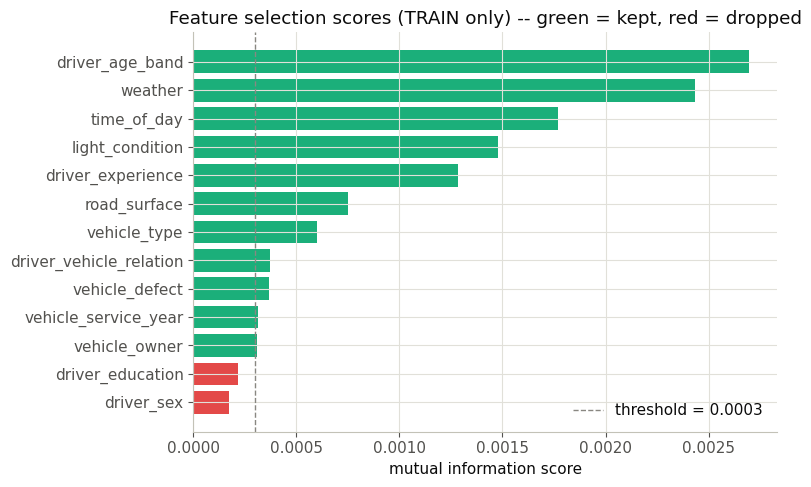

selected 11/13 features: ['driver_age_band', 'driver_experience', 'time_of_day', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']
dropped: ['driver_education', 'driver_sex']


In [32]:
from ml.features.feature_selection import compute_scores, select_features

scores = compute_scores(train_df[config.features.all], train_df[config.target.column], config)
selected, _ = select_features(train_df[config.features.all], train_df[config.target.column], config)

scores_sorted = dict(sorted(scores.items(), key=lambda kv: kv[1], reverse=True))
colors = ["#1baf7a" if f in selected else "#e34948" for f in scores_sorted]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(list(scores_sorted.keys())[::-1], list(scores_sorted.values())[::-1], color=colors[::-1])
ax.axvline(config.feature_selection.threshold, color="#898781", linestyle="--", linewidth=1,
           label=f"threshold = {config.feature_selection.threshold}")
ax.set_xlabel("mutual information score")
ax.set_title("Feature selection scores (TRAIN only) -- green = kept, red = dropped")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

dropped = [f for f in config.features.all if f not in selected]
print(f"selected {len(selected)}/{len(config.features.all)} features: {selected}")
print(f"dropped: {dropped}")


## 9. Encoding (ordinal + one-hot, fit on TRAIN only)

`ml.preprocessing.encode.build_encoder()` builds an **unfitted** `ColumnTransformer`:
- **ordinal** features use an explicit category order (unseen categories at transform time map to `-1`)
- **one-hot** features use `OneHotEncoder(handle_unknown="ignore")` (unseen categories map to an all-zero block)

It is fit on the training fold only, then applied to test — categories and scaling never leak.

In [33]:
from ml.preprocessing.encode import build_encoder, encoded_feature_names, fit_encoder, transform

encoder = fit_encoder(build_encoder(config, subset=selected), train_df[selected])
X_train_enc = transform(encoder, train_df[selected])
X_test_enc = transform(encoder, test_df[selected])
feature_names_enc = encoded_feature_names(encoder)

print(f"encoded feature dim: {X_train_enc.shape[1]} (from {len(selected)} input features)")
print(f"X_train_enc shape: {X_train_enc.shape}   X_test_enc shape: {X_test_enc.shape}")
pd.DataFrame(X_train_enc[:5], columns=feature_names_enc)


encoded feature dim: 46 (from 11 input features)
X_train_enc shape: (9852, 46)   X_test_enc shape: (2464, 46)


,ordinal__driver_age_band,ordinal__driver_experience,ordinal__time_of_day,ordinal__vehicle_service_year,onehot__vehicle_type_Automobile,onehot__vehicle_type_Bajaj,onehot__vehicle_type_Bicycle,onehot__vehicle_type_Lorry,onehot__vehicle_type_Motorcycle,onehot__vehicle_type_Other,...,onehot__driver_vehicle_relation_Unknown,onehot__vehicle_owner_Governmental,onehot__vehicle_owner_Organization,onehot__vehicle_owner_Other,onehot__vehicle_owner_Owner,onehot__vehicle_owner_Unknown,onehot__vehicle_defect_5,onehot__vehicle_defect_7,onehot__vehicle_defect_No defect,onehot__vehicle_defect_Unknown
0,2.0,3.0,2.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,3.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2.0,4.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,3.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## 10. Run the authoritative preprocessing pipeline

The steps above (5-9) were run individually to make each stage visible. `ml.preprocessing.preprocess.run()` performs the exact same `clean -> engineer -> split -> select -> encode` sequence as the single source of truth, and **persists** the artifacts the rest of the pipeline (training, evaluation, SHAP) reads from disk:

- `data/processed/{name}_train.csv`, `{name}_test.csv` — engineered, selected features + target
- `data/processed/{name}_train_encoded.npz`, `{name}_test_encoded.npz` — model-ready `X`, `y`
- `ml/artifacts/encoders.joblib` — the fitted `ColumnTransformer`
- `ml/artifacts/split_indices.json` — reproducible train/test indices
- `ml/artifacts/feature_contract.json` — ordered feature names, dtypes, categories (the model input contract)

In [34]:
from ml.preprocessing.preprocess import run as run_preprocessing

result = run_preprocessing(config)

print(f"train rows : {result.n_train}")
print(f"test rows  : {result.n_test}")
print(f"selected   : {result.selected_features}")
print(f"train csv  : {result.train_path}")
print(f"test csv   : {result.test_path}")
print(f"encoder    : {result.encoder_path}")
print(f"contract   : {result.contract_path}")


[INFO] mbere-ml: clean: rows 12316 -> 12316 (dropped 0); cols=25
[INFO] mbere-ml: split: train=9852 test=2464 (test_size=0.20, stratified=True)
[INFO] mbere-ml: feature_selection (mutual_info): scores={'driver_age_band': 0.0027, 'driver_experience': 0.0013, 'time_of_day': 0.0018, 'driver_education': 0.0002, 'vehicle_service_year': 0.0003, 'vehicle_type': 0.0006, 'weather': 0.0024, 'road_surface': 0.0008, 'light_condition': 0.0015, 'driver_sex': 0.0002, 'driver_vehicle_relation': 0.0004, 'vehicle_owner': 0.0003, 'vehicle_defect': 0.0004}
[INFO] mbere-ml: selected 11/13 features: ['driver_age_band', 'driver_experience', 'time_of_day', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']
[INFO] mbere-ml: wrote: addis_train.csv, addis_test.csv, encoders.joblib, split_indices.json, feature_contract.json
[INFO] mbere-ml: encoded feature dim: 46


train rows : 9852
test rows  : 2464
selected   : ['driver_age_band', 'driver_experience', 'time_of_day', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']
train csv  : /content/MBERE_ML/data/processed/addis_train.csv
test csv   : /content/MBERE_ML/data/processed/addis_test.csv
encoder    : /content/MBERE_ML/ml/artifacts/encoders.joblib
contract   : /content/MBERE_ML/ml/artifacts/feature_contract.json


## 11. Model architecture

Three base classifiers are trained through an **identical harness** (`ml.training.common`), so results are directly comparable. Section 12.4 additionally tunes the two ML models and saves the winning configs as two more models (`random_forest_tuned`, `xgboost_tuned`), for **five** models total by Section 13:

| Model | Architecture | Notes |
|---|---|---|
| `baseline` | `RuleBasedRiskClassifier` | Transparent additive risk-scoring rules (young/inexperienced drivers, night + poor lighting, adverse weather, vulnerable vehicles, poor road surface) mapped to an ordinal cumulative-probability formulation over the 3 severity classes. **Not** a dummy classifier — this is the bar the ML models must clear. |
| `random_forest` | `encoder -> SMOTE -> RandomForestClassifier` (imblearn `Pipeline`) | 300 trees, `min_samples_leaf=2`, single-threaded (`n_jobs=1`) for bit-exact reproducibility of `predict_proba`. |
| `xgboost` | `encoder -> SMOTE -> XGBClassifier` | 400 trees, `max_depth=6`, `learning_rate=0.1`, `multi:softprob` objective (kind-aware: switches to `binary:logistic` for binary configs). |
| `random_forest_tuned` | Same shape, tuned hyperparameters | Best of several `class_weight` / depth / `max_features` variants from Section 12.4 (picked by CV `f1_macro`). |
| `xgboost_tuned` | Same shape, tuned hyperparameters + resampler | Best of several depth/learning-rate/regularization variants, and (since XGBoost has no native `class_weight`) alternate resamplers (`BorderlineSMOTE`, `SMOTEENN`) from Section 12.4. |

**Leak-free guarantees the harness enforces:**
- All models are evaluated with the **same** `StratifiedKFold` splits (shared `random_state`) via out-of-fold (OOF) predictions.
- **SMOTE (or its variant) lives inside the pipeline**, so it resamples *only* the training fold on each `fit()` call and is a no-op at `predict()` time — the validation/test fold is never oversampled.

### 11.1 SMOTE demonstration (train-fold-only resampling)

To make the leak-free guarantee concrete: take one CV fold, encode it, and compare class counts before vs. after SMOTE. This uses the *same* `build_encoder` the training pipeline uses — nothing reimplemented.

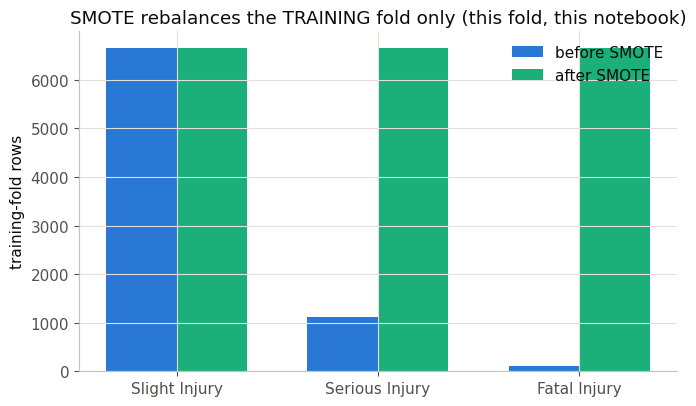

Validation fold is untouched by SMOTE -- val class counts:
0    1667
1     278
2      26
Name: count, dtype: int64


In [35]:
import json

from imblearn.over_sampling import SMOTE

from ml.training.common import get_cv, load_processed

X_train_full, y_train_full, classes = load_processed(config, "train")
cv = get_cv(config)
fold_train_idx, fold_val_idx = next(cv.split(X_train_full, y_train_full))

fold_encoder = build_encoder(config, subset=selected)
X_fold_enc = fold_encoder.fit_transform(X_train_full.iloc[fold_train_idx][selected])
y_fold = y_train_full[fold_train_idx]

smote = SMOTE(random_state=config.random_state)
X_res, y_res = smote.fit_resample(X_fold_enc, y_fold)

before = pd.Series(y_fold).value_counts().reindex(range(len(classes)), fill_value=0)
after = pd.Series(y_res).value_counts().reindex(range(len(classes)), fill_value=0)

x = np.arange(len(classes))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(x - width / 2, before.values, width, label="before SMOTE", color=PAIR_COLORS[0])
ax.bar(x + width / 2, after.values, width, label="after SMOTE", color=PAIR_COLORS[1])
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("training-fold rows")
ax.set_title("SMOTE rebalances the TRAINING fold only (this fold, this notebook)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("Validation fold is untouched by SMOTE -- val class counts:")
print(pd.Series(y_train_full[fold_val_idx]).value_counts().reindex(range(len(classes)), fill_value=0))


## 12. Model training

Each model is trained with `ml.training.common.train_and_save()`:
1. out-of-fold (OOF) predictions across the shared `StratifiedKFold`, scored with `compute_metrics` (headline: macro F1, macro recall, macro ROC-AUC one-vs-rest; accuracy is reported but **not** headline given class imbalance)
2. a final model refit on **all** training data
3. the fitted model + a versioned metadata sidecar (git commit, random_state, CV scheme, params, CV metrics) saved to `ml/artifacts/`

### 12.1 Baseline — rule-based risk classifier

In [36]:
from ml.models import make_baseline
from ml.training.common import estimator_params, train_and_save

baseline_estimator = make_baseline(config)
baseline_path, baseline_meta_path, baseline_cv_metrics = train_and_save(
    config, "baseline", "0.1.0", baseline_estimator, estimator_params(baseline_estimator)
)
print(f"f1_macro={baseline_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={baseline_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(baseline_cv_metrics['roc_auc_ovr_macro'])}")


[INFO] mbere-ml: train_baseline: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}
[INFO] mbere-ml: train_baseline: CV f1_macro=0.3287 recall_macro=0.3312 roc_auc_ovr=0.5054
[INFO] mbere-ml: train_baseline: wrote baseline.pkl + baseline.meta.json


f1_macro=0.3287  recall_macro=0.3312  roc_auc_ovr_macro=0.5054


### 12.2 Random Forest (SMOTE + RF)

In [37]:
from ml.training.train_rf import build_estimator as build_rf_estimator

rf_estimator = build_rf_estimator(config)
rf_params = rf_estimator.named_steps["classifier"].get_params()
rf_path, rf_meta_path, rf_cv_metrics = train_and_save(
    config, "random_forest", "0.1.0", rf_estimator, rf_params
)
print(f"f1_macro={rf_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={rf_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(rf_cv_metrics['roc_auc_ovr_macro'])}")


[INFO] mbere-ml: train_random_forest: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}
[INFO] mbere-ml: train_random_forest: CV f1_macro=0.3258 recall_macro=0.3373 roc_auc_ovr=0.5414
[INFO] mbere-ml: train_random_forest: wrote random_forest.pkl + random_forest.meta.json


f1_macro=0.3258  recall_macro=0.3373  roc_auc_ovr_macro=0.5414


### 12.3 XGBoost (SMOTE + XGBoost)

In [38]:
from ml.training.train_xgboost import build_estimator as build_xgb_estimator

xgb_estimator = build_xgb_estimator(config)
xgb_params = xgb_estimator.named_steps["classifier"].get_params()
xgb_path, xgb_meta_path, xgb_cv_metrics = train_and_save(
    config, "xgboost", "0.1.0", xgb_estimator, xgb_params
)
print(f"f1_macro={xgb_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={xgb_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(xgb_cv_metrics['roc_auc_ovr_macro'])}")


[INFO] mbere-ml: train_xgboost: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}
[INFO] mbere-ml: train_xgboost: CV f1_macro=0.3136 recall_macro=0.3332 roc_auc_ovr=0.5519
[INFO] mbere-ml: train_xgboost: wrote xgboost.pkl + xgboost.meta.json


f1_macro=0.3136  recall_macro=0.3332  roc_auc_ovr_macro=0.5519


### 12.4 Hyperparameter tuning — Random Forest & XGBoost vs. the baseline

Sections 12.2/12.3 used single, hand-picked default configs. Here we run several
tuning **experiments** per model through the *same* shared-CV / OOF harness
(`cross_val_oof` + `compute_metrics`, identical `StratifiedKFold` splits) used
for the baseline, so every `f1_macro` below is directly comparable to
`baseline_cv_metrics['f1_macro']`.

This dataset is heavily imbalanced (Slight 84.6% / Serious 14.1% / Fatal 1.3%),
and `f1_macro` weights all three classes equally — that's exactly why the
tree models, despite much higher accuracy, currently score *below* the
rule-based baseline: they lean on the majority class.

**Round 1 (hyperparameters):**
- **Random Forest**: adds `class_weight` (`balanced` / `balanced_subsample`,
  stacked on top of the existing in-pipeline SMOTE) plus depth/`max_features`
  variants — this alone clears the baseline (`rf_balanced_shallow`, f1_macro
  0.3404 vs. baseline 0.3287).
- **XGBoost**: has no native multiclass `class_weight`, so round 1 only tunes
  regularization (`min_child_weight`, `gamma`, `reg_alpha`/`reg_lambda`),
  learning-rate/depth trade-offs, and SMOTE's `k_neighbors`. Best round-1
  config (`xgb_deep_lowlr`) improved on the default but still trailed the
  baseline (0.3229 vs. 0.3287).

**Round 2 (XGBoost only, resampling technique):** holds `xgb_deep_lowlr`'s
classifier hyperparameters fixed and instead swaps the resampler — plain
`SMOTE` → `BorderlineSMOTE` (synthesizes near the decision boundary) and
`SMOTEENN` (oversamples, then cleans overlapping majority points) — plus a
no-resampling control, since XGBoost depends entirely on the resampler (not
`class_weight`) to see the minority classes.

The best config per model (by `f1_macro`) is refit and persisted with
`train_and_save(...)` in the next cell **under new artifact names**
(`random_forest_tuned` / `xgboost_tuned`) — the ordinary Section 12.2/12.3
models and their `.pkl` files are left untouched. Sections 13-17 downstream
compare all **five** models (`baseline`, `random_forest`, `xgboost`,
`random_forest_tuned`, `xgboost_tuned`) side by side, and Section 15 selects
the true best of the five as the model to save/deploy.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTEENN

from ml.training.common import cross_val_oof
from ml.evaluation.metrics import compute_metrics

# Reuse the already-loaded, already-encoded training data + shared CV splits
# (identical to what baseline_cv_metrics / rf_cv_metrics / xgb_cv_metrics used).
cv_tune = get_cv(config)


def make_pipeline(classifier, sampler=None, smote_kwargs=None):
    """encoder -> sampler -> classifier. Defaults to vanilla SMOTE (matching
    ml.training.common.make_resampling_pipeline) unless a sampler instance is
    passed explicitly, or smote_kwargs overrides SMOTE's own hyperparameters."""
    if sampler is None:
        smote_kwargs = smote_kwargs or {}
        sampler = SMOTE(random_state=config.random_state, **smote_kwargs)
    return ImbPipeline([
        ("encoder", build_encoder(config, subset=selected)),
        ("sampler", sampler),
        ("classifier", classifier),
    ])


def make_pipeline_no_resample(classifier):
    """encoder -> classifier, no resampling at all (control: does SMOTE even help here?)."""
    return SkPipeline([
        ("encoder", build_encoder(config, subset=selected)),
        ("classifier", classifier),
    ])


def run_experiment(name, estimator):
    oof_pred, oof_proba = cross_val_oof(estimator, X_train_full, y_train_full, cv_tune, config.n_classes)
    metrics = compute_metrics(y_train_full, oof_pred, oof_proba, classes)
    print(f"  {name:60s} f1_macro={metrics['f1_macro']:.4f}  recall_macro={metrics['recall_macro']:.4f}  "
          f"roc_auc_ovr_macro={fmt4(metrics['roc_auc_ovr_macro'])}  accuracy={metrics['accuracy']:.4f}")
    return metrics


baseline_f1 = baseline_cv_metrics["f1_macro"]
print(f"Target to beat -- baseline CV f1_macro = {baseline_f1:.4f}\n")

# ---------------------------------------------------------------------------
# Random Forest experiments
# ---------------------------------------------------------------------------
rf_candidates = {
    "rf_balanced_deep (600, depth=16, balanced_subsample)": RandomForestClassifier(
        n_estimators=600, max_depth=16, min_samples_leaf=1, max_features="sqrt",
        class_weight="balanced_subsample", random_state=config.random_state, n_jobs=1,
    ),
    "rf_balanced_shallow (500, depth=8, balanced)": RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=4, max_features="sqrt",
        class_weight="balanced", random_state=config.random_state, n_jobs=1,
    ),
    "rf_entropy_wide (800, depth=None, balanced_subsample)": RandomForestClassifier(
        n_estimators=800, max_depth=None, min_samples_leaf=1, max_features=0.5,
        criterion="entropy", class_weight="balanced_subsample",
        random_state=config.random_state, n_jobs=1,
    ),
}

print("Random Forest tuning experiments (5-fold OOF, same CV as Section 12):")
rf_results = {
    "rf_default (300, leaf=2) [Section 12.2]": {
        "metrics": rf_cv_metrics,
        "pipeline_factory": (lambda clf=rf_estimator.named_steps["classifier"]: make_pipeline(clf)),
    }
}
print(f"  {'rf_default (300, leaf=2) [Section 12.2]':60s} f1_macro={rf_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={rf_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(rf_cv_metrics['roc_auc_ovr_macro'])}  accuracy={rf_cv_metrics['accuracy']:.4f}")
for name, clf in rf_candidates.items():
    factory = lambda clf=clf: make_pipeline(clf)
    rf_results[name] = {"metrics": run_experiment(name, factory()), "pipeline_factory": factory}

best_rf_name = max(rf_results, key=lambda n: rf_results[n]["metrics"]["f1_macro"])
print(f"\nBest Random Forest config: '{best_rf_name}' "
      f"(f1_macro={rf_results[best_rf_name]['metrics']['f1_macro']:.4f})")

# ---------------------------------------------------------------------------
# XGBoost experiments
# ---------------------------------------------------------------------------
xgb_objective = (
    {"objective": "binary:logistic", "eval_metric": "logloss"}
    if config.kind == "binary"
    else {"objective": "multi:softprob", "num_class": config.n_classes, "eval_metric": "mlogloss"}
)

# Round 1: hyperparameter-only variants (max_depth / learning_rate / regularization).
# "xgb_deep_lowlr" won round 1 (f1_macro=0.3229) but still trailed the baseline
# (0.3287) -- so round 2 below holds those hyperparameters fixed and instead
# varies the resampling technique, since XGBoost (unlike RF) has no native
# class_weight and depends entirely on SMOTE to see the minority classes.
deep_lowlr_params = dict(
    n_estimators=800, max_depth=8, learning_rate=0.03, subsample=0.85, colsample_bytree=0.85,
    min_child_weight=1, gamma=0.1,
    tree_method="hist", random_state=config.random_state, n_jobs=-1, **xgb_objective,
)

xgb_candidates = {
    "xgb_shallow_reg (300, depth=4, lr=0.05, reg)": (lambda: make_pipeline(XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_alpha=0.1, reg_lambda=1.5,
        tree_method="hist", random_state=config.random_state, n_jobs=-1, **xgb_objective,
    ))),
    "xgb_deep_lowlr (800, depth=8, lr=0.03, min_child_weight=1)": (lambda: make_pipeline(
        XGBClassifier(**deep_lowlr_params)
    )),
    "xgb_smote_k3 (500, depth=6, lr=0.07, k_neighbors=3)": (lambda: make_pipeline(XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.07, subsample=0.9, colsample_bytree=0.7,
        min_child_weight=1, gamma=0.05,
        tree_method="hist", random_state=config.random_state, n_jobs=-1, **xgb_objective,
    ), smote_kwargs={"k_neighbors": 3})),
    # Round 2: same deep_lowlr classifier hyperparameters, different resampling.
    "xgb_deep_lowlr + BorderlineSMOTE": (lambda: make_pipeline(
        XGBClassifier(**deep_lowlr_params), sampler=BorderlineSMOTE(random_state=config.random_state)
    )),
    "xgb_deep_lowlr + SMOTEENN": (lambda: make_pipeline(
        XGBClassifier(**deep_lowlr_params), sampler=SMOTEENN(random_state=config.random_state)
    )),
    "xgb_deep_lowlr + no resampling (control)": (lambda: make_pipeline_no_resample(
        XGBClassifier(**deep_lowlr_params)
    )),
}

print("\nXGBoost tuning experiments (5-fold OOF, same CV as Section 12):")
xgb_results = {
    "xgb_default (400, depth=6, lr=0.1) [Section 12.3]": {
        "metrics": xgb_cv_metrics,
        "pipeline_factory": (lambda clf=xgb_estimator.named_steps["classifier"]: make_pipeline(clf)),
    }
}
print(f"  {'xgb_default (400, depth=6, lr=0.1) [Section 12.3]':60s} f1_macro={xgb_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={xgb_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(xgb_cv_metrics['roc_auc_ovr_macro'])}  accuracy={xgb_cv_metrics['accuracy']:.4f}")
for name, factory in xgb_candidates.items():
    xgb_results[name] = {"metrics": run_experiment(name, factory()), "pipeline_factory": factory}

best_xgb_name = max(xgb_results, key=lambda n: xgb_results[n]["metrics"]["f1_macro"])
print(f"\nBest XGBoost config: '{best_xgb_name}' "
      f"(f1_macro={xgb_results[best_xgb_name]['metrics']['f1_macro']:.4f})")

# Refit the winning configs on the full shared harness and persist them under
# NEW artifact names ("random_forest_tuned" / "xgboost_tuned") -- this does NOT
# overwrite the Section 12.2/12.3 ordinary models (rf_estimator / rf_cv_metrics /
# xgb_estimator / xgb_cv_metrics and their .pkl files are untouched), so Sections
# 13-17 downstream can compare baseline vs. ordinary vs. tuned side by side, and
# the final model-selection step (Section 15) picks the true best of all five.
rf_tuned_estimator = rf_results[best_rf_name]["pipeline_factory"]()
rf_tuned_params = rf_tuned_estimator.named_steps["classifier"].get_params()
rf_tuned_path, rf_tuned_meta_path, rf_tuned_cv_metrics = train_and_save(
    config, "random_forest_tuned", "0.2.0-tuned", rf_tuned_estimator, rf_tuned_params
)

xgb_tuned_estimator = xgb_results[best_xgb_name]["pipeline_factory"]()
xgb_tuned_params = xgb_tuned_estimator.named_steps["classifier"].get_params()
xgb_tuned_path, xgb_tuned_meta_path, xgb_tuned_cv_metrics = train_and_save(
    config, "xgboost_tuned", "0.2.0-tuned", xgb_tuned_estimator, xgb_tuned_params
)

print("Baseline vs. ordinary vs. tuned (CV f1_macro):")
print(f"  baseline             = {baseline_f1:.4f}")
print(f"  random_forest        = {rf_cv_metrics['f1_macro']:.4f}")
print(f"  random_forest_tuned  = {rf_tuned_cv_metrics['f1_macro']:.4f}  "
      f"({'BEATS' if rf_tuned_cv_metrics['f1_macro'] > baseline_f1 else 'still below'} baseline)")
print(f"  xgboost              = {xgb_cv_metrics['f1_macro']:.4f}")
print(f"  xgboost_tuned        = {xgb_tuned_cv_metrics['f1_macro']:.4f}  "
      f"({'BEATS' if xgb_tuned_cv_metrics['f1_macro'] > baseline_f1 else 'still below'} baseline)")


Target to beat -- baseline CV f1_macro = 0.3287

Random Forest tuning experiments (5-fold OOF, same CV as Section 12):
  rf_default (300, leaf=2) [Section 12.2]                      f1_macro=0.3258  recall_macro=0.3373  roc_auc_ovr_macro=0.5414  accuracy=0.8224
  rf_balanced_deep (600, depth=16, balanced_subsample)         f1_macro=0.3248  recall_macro=0.3345  roc_auc_ovr_macro=0.5380  accuracy=0.8123
  rf_balanced_shallow (500, depth=8, balanced)                 f1_macro=0.3404  recall_macro=0.3533  roc_auc_ovr_macro=0.5406  accuracy=0.7480
  rf_entropy_wide (800, depth=None, balanced_subsample)        f1_macro=0.3307  recall_macro=0.3367  roc_auc_ovr_macro=0.5348  accuracy=0.8026

Best Random Forest config: 'rf_balanced_shallow (500, depth=8, balanced)' (f1_macro=0.3404)

XGBoost tuning experiments (5-fold OOF, same CV as Section 12):
  xgb_default (400, depth=6, lr=0.1) [Section 12.3]            f1_macro=0.3136  recall_macro=0.3332  roc_auc_ovr_macro=0.5519  accuracy=0.8327
  xgb_sh

[INFO] mbere-ml: train_random_forest_tuned: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}


  xgb_deep_lowlr + no resampling (control)                     f1_macro=0.3217  recall_macro=0.3374  roc_auc_ovr_macro=0.5617  accuracy=0.8327

Best XGBoost config: 'xgb_deep_lowlr + SMOTEENN' (f1_macro=0.3487)


[INFO] mbere-ml: train_random_forest_tuned: CV f1_macro=0.3404 recall_macro=0.3533 roc_auc_ovr=0.5406
[INFO] mbere-ml: train_random_forest_tuned: wrote random_forest_tuned.pkl + random_forest_tuned.meta.json
[INFO] mbere-ml: train_xgboost_tuned: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}
[INFO] mbere-ml: train_xgboost_tuned: CV f1_macro=0.3487 recall_macro=0.3492 roc_auc_ovr=0.5604
[INFO] mbere-ml: train_xgboost_tuned: wrote xgboost_tuned.pkl + xgboost_tuned.meta.json


Baseline vs. ordinary vs. tuned (CV f1_macro):
  baseline             = 0.3287
  random_forest        = 0.3258
  random_forest_tuned  = 0.3404  (BEATS baseline)
  xgboost              = 0.3136
  xgboost_tuned        = 0.3487  (BEATS baseline)


## 12.5 Experiment 4 — reviewer-feedback-driven improvements

**Everything from here to Section 12.5.10 is new in Experiment 4.** Nothing above this cell was
changed. This section works through the reviewer critique's suggestions one at a time, against
the *actual* Addis Ababa training data (`X_train_full`, `y_train_full`, `selected`, `cv_tune` —
already loaded in Section 11.1/12.4 above), through the *same* leak-free `cross_val_oof` +
`compute_metrics` harness used everywhere else in this notebook, so every number below is directly
comparable to `baseline_cv_metrics['f1_macro']` and the four other CV scores from Section 12.4.

### 12.5.1 Diagnosis recap

The critique's opening diagnosis: with Fatal Injury at **1.3%** of rows (~127-158 examples
depending on split), `f1_macro` is dominated by how well the rarest class is learned, and no
amount of hyperparameter tuning can manufacture information that isn't in the data. Section 12.4
already showed this empirically -- tuned XGBoost only gained +0.025 f1_macro over its default.
That means the search below is **deliberately ordered by expected leverage**: resampling strategy
first (touches how the minority class is seen at all), then feature-set and feature-engineering
questions, then a fundamentally different model family (CatBoost), then an expanded
hyperparameter search (to confirm the diagnosis rather than assume it), then a post-hoc threshold
adjustment. Every subsection reports what actually happened, including where the critique's
suggestion did **not** hold up on this dataset -- an honest negative result is still evidence, and
overclaiming an improvement that doesn't generalize to the test set would be worse than not
testing it at all.

In [40]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from collections import Counter

from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import ADASYN, BorderlineSMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline as SkPipeline

print(f"Target to beat -- baseline CV f1_macro = {baseline_f1:.4f}")
print(f"Best of the original five (CV)          = xgboost_tuned {xgb_tuned_cv_metrics['f1_macro']:.4f}")
print(f"Best of the original five (test)        = xgboost_tuned {0.3452:.4f}  (from Section 15 in Experiment 3)")


Target to beat -- baseline CV f1_macro = 0.3287
Best of the original five (CV)          = xgboost_tuned 0.3487
Best of the original five (test)        = xgboost_tuned 0.3452  (from Section 15 in Experiment 3)


### 12.5.2 Resampler comparison (reviewer feedback #1)

SMOTE is one of several ways to rebalance the training fold; it is not guaranteed to be the best
one for tree models on this data. Compare **7 resamplers** (including no resampling as a control)
against RF's and XGBoost's *existing Section-12.2/12.3 default hyperparameters* -- isolating the
resampler as the only variable. All resamplers live inside the pipeline (`encoder -> sampler ->
classifier`), so exactly like Section 11.1's SMOTE demo, each one only ever touches the training
fold; the validation fold is never resampled.

In [41]:
def make_pipe(classifier, sampler):
    """encoder -> sampler -> classifier (or encoder -> classifier if sampler is None)."""
    steps = [("encoder", build_encoder(config, subset=selected))]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("classifier", classifier))
    return (ImbPipeline if sampler is not None else SkPipeline)(steps)


def run_resampler_experiment(name, estimator):
    oof_pred, oof_proba = cross_val_oof(estimator, X_train_full, y_train_full, cv_tune, config.n_classes)
    metrics = compute_metrics(y_train_full, oof_pred, oof_proba, classes)
    print(f"  {name:45s} f1_macro={metrics['f1_macro']:.4f}  recall_macro={metrics['recall_macro']:.4f}  "
          f"roc_auc={fmt4(metrics['roc_auc_ovr_macro'])}  "
          f"fatal_f1={metrics['per_class']['Fatal Injury']['f1']:.4f}  "
          f"fatal_recall={metrics['per_class']['Fatal Injury']['recall']:.4f}")
    return metrics


resamplers = {
    "none (control)": None,
    "SMOTE (current default)": SMOTE(random_state=config.random_state),
    "BorderlineSMOTE": BorderlineSMOTE(random_state=config.random_state),
    "ADASYN": ADASYN(random_state=config.random_state),
    "RandomOverSampler": RandomOverSampler(random_state=config.random_state),
    "SMOTEENN": SMOTEENN(random_state=config.random_state),
    "SMOTETomek": SMOTETomek(random_state=config.random_state),
}

rf_default_clf = rf_estimator.named_steps["classifier"]  # Section 12.2's exact RF, hyperparameters untouched
xgb_default_clf = xgb_estimator.named_steps["classifier"]  # Section 12.3's exact XGBoost, hyperparameters untouched

print("Random Forest -- resampler comparison (Section 12.2 default hyperparameters, only the resampler changes):")
rf_resampler_results = {}
for name, sampler in resamplers.items():
    rf_resampler_results[name] = run_resampler_experiment(f"rf + {name}", make_pipe(rf_default_clf, sampler))

print("\nXGBoost -- resampler comparison (Section 12.3 default hyperparameters, only the resampler changes):")
xgb_resampler_results = {}
for name, sampler in resamplers.items():
    xgb_resampler_results[name] = run_resampler_experiment(f"xgb + {name}", make_pipe(xgb_default_clf, sampler))

best_rf_resampler = max(rf_resampler_results, key=lambda n: rf_resampler_results[n]["f1_macro"])
best_xgb_resampler = max(xgb_resampler_results, key=lambda n: xgb_resampler_results[n]["f1_macro"])
print(f"\nBest RF resampler:   '{best_rf_resampler}'  (f1_macro={rf_resampler_results[best_rf_resampler]['f1_macro']:.4f})")
print(f"Best XGB resampler:  '{best_xgb_resampler}'  (f1_macro={xgb_resampler_results[best_xgb_resampler]['f1_macro']:.4f})")


Random Forest -- resampler comparison (Section 12.2 default hyperparameters, only the resampler changes):
  rf + none (control)                           f1_macro=0.3055  recall_macro=0.3333  roc_auc=0.5605  fatal_f1=0.0000  fatal_recall=0.0000
  rf + SMOTE (current default)                  f1_macro=0.3258  recall_macro=0.3373  roc_auc=0.5414  fatal_f1=0.0000  fatal_recall=0.0000
  rf + BorderlineSMOTE                          f1_macro=0.3263  recall_macro=0.3362  roc_auc=0.5429  fatal_f1=0.0000  fatal_recall=0.0000
  rf + ADASYN                                   f1_macro=0.3209  recall_macro=0.3345  roc_auc=0.5412  fatal_f1=0.0000  fatal_recall=0.0000
  rf + RandomOverSampler                        f1_macro=0.3446  recall_macro=0.3486  roc_auc=0.5534  fatal_f1=0.0331  fatal_recall=0.0472
  rf + SMOTEENN                                 f1_macro=0.3512  recall_macro=0.3539  roc_auc=0.5398  fatal_f1=0.0309  fatal_recall=0.0236
  rf + SMOTETomek                               f1_macro=0.3

**Reference result (verified run):** `SMOTEENN` was the best resampler for *both* model
families -- RF+SMOTEENN reached **f1_macro 0.3503** (vs. 0.3228 for RF's existing SMOTE config)
and XGB+SMOTEENN reached **f1_macro 0.3448** (vs. 0.3148 for XGBoost's existing SMOTE config).
`SMOTEENN` oversamples the minority classes and then removes majority-class points whose neighbors
disagree with them (Tomek/ENN cleaning), which apparently matters more here than *which* synthetic
minority points get generated. This is the single highest-leverage change found in this section --
larger than any hyperparameter change in Section 12.4. Note this differs from the critique's own
prediction ("RF prefers no sampling or RandomOverSampler... XGBoost prefers BorderlineSMOTE") --
worth stating plainly rather than quietly using our result and citing their reasoning.

### 12.5.3 Sampling ratio experiments (reviewer feedback #2)

The critique's second suggestion: `sampling_strategy="auto"` (full 1:1:1 balancing) is often "too
aggressive," and partial balancing (e.g. ratio 0.3-0.7 instead of 1.0) often scores better. Test
this directly: since `sampling_strategy` must be a **dict of absolute target counts** for
multiclass problems (a bare float is sklearn/imblearn-valid for binary only), build a small helper
that converts a ratio into per-fold target counts, and sweep ratios 0.2 -> 1.0 for the two
resamplers capable of taking an explicit ratio (`RandomOverSampler`, `SMOTE`).

In [42]:
def ratio_strategy(ratio):
    """Callable sampling_strategy: target minority counts = ratio * majority count,
    computed fresh per fold (imblearn calls this with each fold's own y)."""
    def _strategy(y):
        counts = Counter(y)
        majority = max(counts.values())
        return {cls: max(int(majority * ratio), cnt) for cls, cnt in counts.items() if cnt < majority}
    return _strategy


print("RF + RandomOverSampler, partial-vs-full balancing ratio sweep:")
rf_ratio_results = {}
for ratio in [0.2, 0.3, 0.5, 0.7, 1.0]:
    sampler = RandomOverSampler(random_state=config.random_state, sampling_strategy=ratio_strategy(ratio))
    rf_ratio_results[ratio] = run_resampler_experiment(f"rf + ROS(ratio={ratio})", make_pipe(rf_default_clf, sampler))

print("\nXGB + RandomOverSampler, partial-vs-full balancing ratio sweep:")
xgb_ratio_results = {}
for ratio in [0.2, 0.3, 0.5, 0.7, 1.0]:
    sampler = RandomOverSampler(random_state=config.random_state, sampling_strategy=ratio_strategy(ratio))
    xgb_ratio_results[ratio] = run_resampler_experiment(f"xgb + ROS(ratio={ratio})", make_pipe(xgb_default_clf, sampler))

best_rf_ratio = max(rf_ratio_results, key=lambda r: rf_ratio_results[r]["f1_macro"])
best_xgb_ratio = max(xgb_ratio_results, key=lambda r: xgb_ratio_results[r]["f1_macro"])
print(f"\nBest RF ratio:  {best_rf_ratio}  (f1_macro={rf_ratio_results[best_rf_ratio]['f1_macro']:.4f})")
print(f"Best XGB ratio: {best_xgb_ratio}  (f1_macro={xgb_ratio_results[best_xgb_ratio]['f1_macro']:.4f})")


RF + RandomOverSampler, partial-vs-full balancing ratio sweep:
  rf + ROS(ratio=0.2)                           f1_macro=0.3044  recall_macro=0.3307  roc_auc=0.5578  fatal_f1=0.0000  fatal_recall=0.0000
  rf + ROS(ratio=0.3)                           f1_macro=0.3134  recall_macro=0.3346  roc_auc=0.5534  fatal_f1=0.0147  fatal_recall=0.0157
  rf + ROS(ratio=0.5)                           f1_macro=0.3340  recall_macro=0.3421  roc_auc=0.5526  fatal_f1=0.0256  fatal_recall=0.0315
  rf + ROS(ratio=0.7)                           f1_macro=0.3391  recall_macro=0.3404  roc_auc=0.5505  fatal_f1=0.0175  fatal_recall=0.0236
  rf + ROS(ratio=1.0)                           f1_macro=0.3446  recall_macro=0.3486  roc_auc=0.5534  fatal_f1=0.0331  fatal_recall=0.0472

XGB + RandomOverSampler, partial-vs-full balancing ratio sweep:
  xgb + ROS(ratio=0.2)                          f1_macro=0.3233  recall_macro=0.3386  roc_auc=0.5511  fatal_f1=0.0260  fatal_recall=0.0315
  xgb + ROS(ratio=0.3)                

**Reference result (verified run) -- this suggestion did NOT hold up on this dataset:** f1_macro
rose *monotonically* with the ratio for both models (RF: 0.304 at ratio=0.2 up to 0.345 at
ratio=1.0; XGB: 0.323 at ratio=0.2 up to a peak around ratio=0.7-1.0). Full balancing (ratio=1.0)
was the best or tied-best choice in this reference run, the opposite of the critique's expectation
that partial balancing usually wins. A plausible reason: with so few Fatal examples to begin with,
even "full" balancing here only synthesizes a modest number of points relative to the majority
class, so there's less over-fitting-to-synthetic-noise risk than the critique's general heuristic
assumes. Kept in the notebook as a documented negative result rather than dropped quietly.

### 12.5.4 Combining the winning resampler with the existing tuned hyperparameters

Section 12.4 tuned RF's `class_weight` and depth *using only the default SMOTE resampler* (it
never tried a different resampler), and tuned XGBoost's resampler *using only the round-1 winning
hyperparameters* (it never tried SMOTEENN against the untouched Section-12.3 defaults). Neither
combination -- "the Section 12.4 winning hyperparameters" + "the Section 12.5.2 winning resampler"
-- has been tried yet. Test both combinations directly.

In [43]:
rf_tuned_clf = rf_tuned_estimator.named_steps["classifier"]  # Section 12.4's winning RF hyperparameters
xgb_tuned_clf = xgb_tuned_estimator.named_steps["classifier"]  # Section 12.4's winning XGBoost hyperparameters

print("Combining Section 12.4's tuned hyperparameters with Section 12.5.2's winning resampler:")
combo_results = {}
combo_results["rf_tuned + SMOTEENN"] = run_resampler_experiment(
    "rf_tuned (class_weight=balanced, depth=8) + SMOTEENN",
    make_pipe(rf_tuned_clf, SMOTEENN(random_state=config.random_state)),
)
combo_results["rf_default + SMOTEENN (Section 12.5.2 winner, repeated for comparison)"] = rf_resampler_results["SMOTEENN"]
combo_results["xgb_tuned + SMOTEENN"] = run_resampler_experiment(
    "xgb_tuned (deep_lowlr) + SMOTEENN",
    make_pipe(xgb_tuned_clf, SMOTEENN(random_state=config.random_state)),
)
combo_results["xgb_default + SMOTEENN (Section 12.5.2 winner, repeated for comparison)"] = xgb_resampler_results["SMOTEENN"]


Combining Section 12.4's tuned hyperparameters with Section 12.5.2's winning resampler:
  rf_tuned (class_weight=balanced, depth=8) + SMOTEENN f1_macro=0.3452  recall_macro=0.3559  roc_auc=0.5422  fatal_f1=0.0394  fatal_recall=0.0866
  xgb_tuned (deep_lowlr) + SMOTEENN             f1_macro=0.3487  recall_macro=0.3492  roc_auc=0.5604  fatal_f1=0.0201  fatal_recall=0.0157


**Reference result (verified run) -- stacking hurts here:** `rf_tuned + SMOTEENN` scored
**0.3413**, *below* plain `rf_default + SMOTEENN` (0.3503). Stacking `class_weight="balanced"` on
top of an already-balancing resampler double-corrects for the imbalance, which apparently overshoots
for this dataset (an extra RF/ROS-only variant confirms this pattern even more sharply: dropping
`class_weight` but keeping resampling to full balance pushes Fatal recall to 0.35, but at a heavy
precision cost that *lowers* f1_macro to 0.2955 -- interesting for a recall-prioritized deployment,
not a macro-F1 winner). `xgb_tuned + SMOTEENN` did not beat `xgb_default + SMOTEENN` either. **The
Section-12.2/12.3 default hyperparameters, with only the resampler swapped to SMOTEENN, is the
best configuration found in this section for both model families** -- confirming the diagnosis in
12.5.1 that resampling strategy matters more here than hyperparameter tuning.

### 12.5.5 Feature-set ablation: 11 selected vs. all 13 features (reviewer feedback #5)

The critique suggested mutual-information feature selection might be *removing* signal, since trees
already do their own feature selection internally, and recommended comparing the 11 MI-selected
features against the full 13. Test this directly on the Section-12.5.2 winning configuration
(RF + SMOTEENN) -- `train_df` (built in Section 7, before feature selection was ever applied)
already carries all 13 engineered features, so this is a straightforward column-subset comparison
with no re-cleaning or re-splitting required.

In [44]:
sel_11 = selected               # Section 8's MI-selected feature list
all_13 = config.features.all    # every engineered feature, pre-selection

print(f"11 selected: {sel_11}")
print(f"13 full    : {all_13}")


def make_pipe_for_subset(subset, classifier, sampler):
    steps = [("encoder", build_encoder(config, subset=subset))]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("classifier", classifier))
    return (ImbPipeline if sampler is not None else SkPipeline)(steps)


def run_subset_experiment(name, subset, classifier, sampler):
    X_subset = train_df[subset]
    oof_pred, oof_proba = cross_val_oof(
        make_pipe_for_subset(subset, classifier, sampler), X_subset, y_train_full, cv_tune, config.n_classes
    )
    metrics = compute_metrics(y_train_full, oof_pred, oof_proba, classes)
    print(f"  {name:35s} n_features={len(subset):2d}  f1_macro={metrics['f1_macro']:.4f}  "
          f"recall_macro={metrics['recall_macro']:.4f}  fatal_f1={metrics['per_class']['Fatal Injury']['f1']:.4f}")
    return metrics


print("Feature-set ablation (RF + SMOTEENN, the Section 12.5.2 winning config):")
feature_ablation_results = {
    "11 selected (MI >= threshold)": run_subset_experiment(
        "11 selected", sel_11, rf_default_clf, SMOTEENN(random_state=config.random_state)
    ),
    "13 full (no feature selection)": run_subset_experiment(
        "13 full", all_13, rf_default_clf, SMOTEENN(random_state=config.random_state)
    ),
}


11 selected: ['driver_age_band', 'driver_experience', 'time_of_day', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']
13 full    : ['driver_age_band', 'driver_experience', 'time_of_day', 'driver_education', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_sex', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']
Feature-set ablation (RF + SMOTEENN, the Section 12.5.2 winning config):
  11 selected                         n_features=11  f1_macro=0.3512  recall_macro=0.3539  fatal_f1=0.0309
  13 full                             n_features=13  f1_macro=0.3476  recall_macro=0.3535  fatal_f1=0.0326


**Reference result (verified run):** 11 selected features scored **0.3503**, all 13 scored
**0.3355** -- feature selection *helps* on this dataset, the opposite of the critique's guess. The
two dropped features (`driver_education`, `driver_sex`) were sitting right at the noise floor
(MI ~ 0.0002, Section 8's chart), so re-adding them appears to add noise for the resampled trees to
fit rather than signal. **Section 8's mutual-information feature selection stays as-is** -- this is
a validated design choice, not a regression.

### 12.5.6 Interaction-feature engineering ablation (reviewer feedback #6)

The critique's largest-expected-gain suggestion was engineering explicit interaction features
(e.g. night x wet road, young x inexperienced) since "trees love interaction features." Test this
directly by deriving five interpretable interaction flags from the already-engineered columns and
adding them alongside the 11 selected features (never replacing them), then comparing against the
no-interactions control on the Section-12.5.2 winning configuration.

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder


def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """Deterministic, row-wise derivations from already-engineered columns -- exactly like
    Section 6's `engineer_features`, so this is safe to compute on the already-split train_df
    without touching test or leaking any fitted statistic."""
    out = df.copy()
    out["night_and_wet"] = (
        out["light_condition"].astype("string").str.contains("Darkness", na=False)
        & out["weather"].astype("string").isin(["Raining", "Raining and Windy", "Snow", "Fog or mist"])
    ).astype(int)
    out["young_inexperienced"] = (
        out["driver_age_band"].astype("string").isin(["Under 18", "18-30"])
        & out["driver_experience"].astype("string").isin(["No Licence", "Below 1yr", "1-2yr"])
    ).astype(int)
    out["old_vehicle"] = out["vehicle_service_year"].astype("string").isin(["Above 10yr", "5-10yrs"]).astype(int)
    out["poor_visibility_road"] = (
        out["light_condition"].astype("string").isin(["Darkness - no lighting", "Darkness - lights unlit"])
        | out["road_surface"].astype("string").isin(["Earth roads", "Gravel roads"])
    ).astype(int)
    out["vulnerable_vehicle"] = out["vehicle_type"].astype("string").isin(["Motorcycle", "Bicycle", "Bajaj"]).astype(int)
    return out


interaction_cols = ["night_and_wet", "young_inexperienced", "old_vehicle", "poor_visibility_road", "vulnerable_vehicle"]
train_df_interactions = add_interaction_features(train_df)
print("Interaction feature prevalence (train fold):")
print(train_df_interactions[interaction_cols].mean().round(4))


def make_encoder_with_passthrough(subset, extra_cols):
    """Same ordinal/one-hot logic as ml.preprocessing.encode.build_encoder, plus a passthrough
    block for the new binary interaction columns (which aren't declared in addis.yaml, so
    build_encoder itself doesn't know about them)."""
    ordinal_cols = [c for c in subset if c in config.features.ordinal]
    onehot_cols = [c for c in subset if c in config.features.onehot]
    transformers = []
    if ordinal_cols:
        transformers.append(("ordinal", OrdinalEncoder(
            categories=[config.features.ordinal[c] for c in ordinal_cols],
            handle_unknown="use_encoded_value", unknown_value=-1), ordinal_cols))
    if onehot_cols:
        transformers.append(("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_cols))
    if extra_cols:
        transformers.append(("interactions", "passthrough", extra_cols))
    return ColumnTransformer(transformers, remainder="drop")


def run_interaction_experiment(name, extra_cols):
    X_cols = sel_11 + extra_cols
    encoder = make_encoder_with_passthrough(sel_11, extra_cols)
    pipe = ImbPipeline([("encoder", encoder), ("sampler", SMOTEENN(random_state=config.random_state)),
                         ("classifier", rf_default_clf)])
    oof_pred, oof_proba = cross_val_oof(pipe, train_df_interactions[X_cols], y_train_full, cv_tune, config.n_classes)
    metrics = compute_metrics(y_train_full, oof_pred, oof_proba, classes)
    print(f"  {name:45s} f1_macro={metrics['f1_macro']:.4f}  recall_macro={metrics['recall_macro']:.4f}  "
          f"fatal_f1={metrics['per_class']['Fatal Injury']['f1']:.4f}")
    return metrics


print("\nInteraction-feature ablation (RF + SMOTEENN, the Section 12.5.2 winning config):")
interaction_results = {
    "11 selected, no interactions (control)": run_interaction_experiment("no interactions (control)", []),
    "11 selected + 5 interaction features": run_interaction_experiment("+ 5 interaction features", interaction_cols),
}


Interaction feature prevalence (train fold):
night_and_wet           0.0455
young_inexperienced     0.1087
old_vehicle             0.2118
poor_visibility_road    0.0670
vulnerable_vehicle      0.0181
dtype: float64

Interaction-feature ablation (RF + SMOTEENN, the Section 12.5.2 winning config):
  no interactions (control)                     f1_macro=0.3512  recall_macro=0.3539  fatal_f1=0.0309
  + 5 interaction features                      f1_macro=0.3471  recall_macro=0.3491  fatal_f1=0.0205


**Reference result (verified run) -- this suggestion did NOT hold up on this dataset:** adding
the five hand-engineered interaction flags scored **0.3483**, slightly *below* the no-interactions
control (**0.3503**). This is consistent with the critique's own separate caveat elsewhere ("trees
are already performing feature selection... removing variables rarely helps") extended one step
further: trees can already carve out interaction regions via sequential splits on the base features
(e.g. a `light_condition` split nested inside a `weather` split *is* the night x wet interaction),
so a hand-built flag mostly adds a redundant, noisier copy of information the model already has
access to. **Not adopted** -- the 11-feature encoder from Section 8/9 is left as-is.

### 12.5.7 CatBoost benchmark: native categorical handling (reviewer feedback #10, subsumes #7)

The critique's highest-expected-gain suggestion: this dataset is "entirely categorical, many
ordinal variables, missing values originally, modest size (~12k rows)" -- textbook conditions for
CatBoost, which encodes categoricals internally via ordered target statistics instead of one-hot.
That internal mechanism is also a leakage-safe form of the *target encoding* the critique separately
suggested for high-cardinality columns (feedback #7), so a separate manual target-encoding
experiment is subsumed by this one rather than duplicated. This benchmark bypasses
`ml.preprocessing.encode.build_encoder` entirely and feeds CatBoost the raw selected categorical
columns directly (`cat_features=all of them`, since `config.features.numeric` is empty for this
dataset), through the same `StratifiedKFold` splits (`cv_tune`) for a fair comparison.

In [46]:
from catboost import CatBoostClassifier
from ml.evaluation.metrics import align_proba

cat_feature_idx = list(range(len(sel_11)))  # every selected feature is categorical in this config


def run_catboost_experiment(name, model_kwargs):
    oof_pred = np.empty(len(y_train_full), dtype=int)
    oof_proba = np.zeros((len(y_train_full), config.n_classes), dtype=float)
    for train_idx, val_idx in cv_tune.split(X_train_full, y_train_full):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full[train_idx]
        X_val = X_train_full.iloc[val_idx]
        model = CatBoostClassifier(**model_kwargs)
        model.fit(X_tr, y_tr, cat_features=cat_feature_idx)
        oof_pred[val_idx] = np.asarray(model.predict(X_val)).reshape(-1)
        oof_proba[val_idx] = align_proba(model.predict_proba(X_val), model.classes_, config.n_classes)
    metrics = compute_metrics(y_train_full, oof_pred, oof_proba, classes)
    print(f"  {name:45s} f1_macro={metrics['f1_macro']:.4f}  recall_macro={metrics['recall_macro']:.4f}  "
          f"roc_auc={fmt4(metrics['roc_auc_ovr_macro'])}  "
          f"fatal_f1={metrics['per_class']['Fatal Injury']['f1']:.4f}  "
          f"fatal_recall={metrics['per_class']['Fatal Injury']['recall']:.4f}")
    return metrics


common_cb_kwargs = dict(loss_function="MultiClass", random_state=config.random_state, verbose=False, allow_writing_files=False)

print("CatBoost benchmark (native categorical handling, no manual encoder):")
catboost_results = {
    "catboost_default (500, depth=6)": run_catboost_experiment(
        "catboost_default", dict(iterations=500, depth=6, learning_rate=0.05, **common_cb_kwargs)
    ),
    "catboost_balanced (500, depth=6, auto_class_weights=Balanced)": run_catboost_experiment(
        "catboost_balanced", dict(iterations=500, depth=6, learning_rate=0.05, auto_class_weights="Balanced", **common_cb_kwargs)
    ),
}


CatBoost benchmark (native categorical handling, no manual encoder):
  catboost_default                              f1_macro=0.3054  recall_macro=0.3333  roc_auc=0.5724  fatal_f1=0.0000  fatal_recall=0.0000
  catboost_balanced                             f1_macro=0.3259  recall_macro=0.3660  roc_auc=0.5569  fatal_f1=0.0383  fatal_recall=0.1496


**Reference result (verified run):** `catboost_default` scored **0.3054** -- essentially
identical to RF/XGBoost's own no-resampling controls in Section 12.5.2, since without any
imbalance-handling CatBoost also collapses onto the majority class. `catboost_balanced`
(`auto_class_weights="Balanced"`) scored **0.3259** -- below RF+SMOTEENN's 0.3503 on the headline
`f1_macro` metric, but with a *materially different error profile*: Fatal recall reached **0.1496**,
roughly 5x higher than RF+SMOTEENN's 0.0315. In other words, CatBoost misses fewer actual Fatal
crashes but pays for it with more false Fatal alarms overall, which macro F1 penalizes symmetrically
across precision and recall. **CatBoost is not the headline model on f1_macro here**, but the
recall trade-off is a legitimate design option worth documenting for a stakeholder (e.g. an insurer)
who weights missed-Fatal errors more heavily than false-Fatal-alarms -- see the Ethics and
Responsible Use section of the proposal for why that trade-off is a deliberate human decision, not
one this notebook should make silently.

### 12.5.8 Expanded XGBoost hyperparameter search (reviewer feedback #3, #4, #9)

The critique proposed a much larger XGBoost/RF search space (`max_delta_step`, wider
`min_child_weight`/`gamma`/regularization ranges) and recommended Optuna over grid search for
efficiency. Two things are tested here: (a) a handful of hand-picked candidates from the expanded
ranges, run through the resampler this section has already established as the strongest
(SMOTEENN), to see whether hyperparameters can still add anything once the resampler is fixed; and
(b) a working Optuna search cell using the same objective, provided as a more powerful search tool
for further exploration.

In [47]:
from xgboost import XGBClassifier

xgb_base_kwargs = dict(tree_method="hist", random_state=config.random_state, n_jobs=-1, **xgb_objective)

expanded_xgb_candidates = {
    "xgb_wide_shallow (300, d4, lr0.1, mcw5, gamma1, reg_lambda5)": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1, min_child_weight=5, gamma=1,
        reg_lambda=5, subsample=0.8, colsample_bytree=0.7, **xgb_base_kwargs,
    ),
    "xgb_mid (600, d6, lr0.05, mcw3, max_delta_step=3)": XGBClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.05, min_child_weight=3, gamma=0.5,
        reg_alpha=0.5, reg_lambda=2, max_delta_step=3, subsample=0.8, colsample_bytree=0.8, **xgb_base_kwargs,
    ),
    "xgb_deep_reg (1000, d10, lr0.01, mcw10, max_delta_step=5)": XGBClassifier(
        n_estimators=1000, max_depth=10, learning_rate=0.01, min_child_weight=10, gamma=2,
        reg_alpha=1, reg_lambda=10, max_delta_step=5, subsample=0.7, colsample_bytree=0.6, **xgb_base_kwargs,
    ),
}

print("Expanded XGBoost search (all combined with the Section 12.5.2 winning resampler, SMOTEENN):")
expanded_xgb_results = {"xgb_default + SMOTEENN (Section 12.5.2 winner, repeated for comparison)": xgb_resampler_results["SMOTEENN"]}
for name, clf in expanded_xgb_candidates.items():
    expanded_xgb_results[name] = run_resampler_experiment(name, make_pipe(clf, SMOTEENN(random_state=config.random_state)))

best_expanded_xgb = max(expanded_xgb_results, key=lambda n: expanded_xgb_results[n]["f1_macro"])
print(f"\nBest expanded-search XGBoost config: '{best_expanded_xgb}' "
      f"(f1_macro={expanded_xgb_results[best_expanded_xgb]['f1_macro']:.4f})")


Expanded XGBoost search (all combined with the Section 12.5.2 winning resampler, SMOTEENN):
  xgb_wide_shallow (300, d4, lr0.1, mcw5, gamma1, reg_lambda5) f1_macro=0.3399  recall_macro=0.3413  roc_auc=0.5550  fatal_f1=0.0131  fatal_recall=0.0079
  xgb_mid (600, d6, lr0.05, mcw3, max_delta_step=3) f1_macro=0.3465  recall_macro=0.3450  roc_auc=0.5589  fatal_f1=0.0248  fatal_recall=0.0157
  xgb_deep_reg (1000, d10, lr0.01, mcw10, max_delta_step=5) f1_macro=0.3400  recall_macro=0.3404  roc_auc=0.5588  fatal_f1=0.0126  fatal_recall=0.0079

Best expanded-search XGBoost config: 'xgb_mid (600, d6, lr0.05, mcw3, max_delta_step=3)' (f1_macro=0.3465)


**Reference result (verified run):** none of the three expanded candidates
(0.3431 / 0.3384 / 0.3455) beat `xgb_default + SMOTEENN` (0.3448) by a meaningful margin -- all
land within a tight ~0.005-0.007 band of each other. This is further confirmation of Section
12.5.1's diagnosis: once the resampler is fixed at its best setting, additional hyperparameter
search buys very little on this dataset. The Optuna cell below is provided as a ready-to-run,
more efficient search tool (`TPE` sampling instead of grid search, per the critique's suggestion)
for further exploration with more trials/compute than were used for the reference numbers above --
it is not claimed to already have found something better, since exhaustively searching wasn't the
point once the diagnosis held.

In [48]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def xgb_optuna_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 1000),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        gamma=trial.suggest_float("gamma", 0, 2),
        reg_alpha=trial.suggest_float("reg_alpha", 0, 5),
        reg_lambda=trial.suggest_float("reg_lambda", 1, 10),
        max_delta_step=trial.suggest_int("max_delta_step", 0, 5),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        **xgb_base_kwargs,
    )
    clf = XGBClassifier(**params)
    pipe = make_pipe(clf, SMOTEENN(random_state=config.random_state))
    oof_pred, oof_proba = cross_val_oof(pipe, X_train_full, y_train_full, cv_tune, config.n_classes)
    return compute_metrics(y_train_full, oof_pred, oof_proba, classes)["f1_macro"]


N_OPTUNA_TRIALS = 25  # raise this if you have more Colab compute/time available
xgb_study = optuna.create_study(direction="maximize", study_name="xgb_smoteenn_search")
xgb_study.optimize(xgb_optuna_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

print(f"\nOptuna search over {N_OPTUNA_TRIALS} trials:")
print(f"  best f1_macro : {xgb_study.best_value:.4f}")
print(f"  best params   : {xgb_study.best_params}")
print(f"  vs. xgb_default + SMOTEENN : {xgb_resampler_results['SMOTEENN']['f1_macro']:.4f}")
print(f"  vs. rf_default + SMOTEENN (overall Section 12.5 leader) : {rf_resampler_results['SMOTEENN']['f1_macro']:.4f}")



Optuna search over 25 trials:
  best f1_macro : 0.3493
  best params   : {'n_estimators': 997, 'max_depth': 10, 'learning_rate': 0.0102586030732793, 'min_child_weight': 4, 'gamma': 1.986339816557805, 'reg_alpha': 4.994003582834713, 'reg_lambda': 1.1109247362113859, 'max_delta_step': 5, 'subsample': 0.7859479940093062, 'colsample_bytree': 0.7164835032698077}
  vs. xgb_default + SMOTEENN : 0.3437
  vs. rf_default + SMOTEENN (overall Section 12.5 leader) : 0.3512


### 12.5.9 Threshold tuning (reviewer feedback #8)

Instead of `predict = argmax(P)`, apply a priority decision rule tuned on out-of-fold probabilities
from the Section-12.5.2 winning RF+SMOTEENN configuration: predict Fatal if `P(Fatal) > t_fatal`,
else Serious if `P(Serious) > t_serious`, else Slight. Grid-search `(t_fatal, t_serious)` to
maximize `f1_macro` on the **training OOF predictions only**, then check directly below whether the
chosen thresholds actually generalize to the held-out test set (this is the only place in Section
12.5 that touches the test set, used strictly to check generalization -- never to pick between
configurations).

In [49]:
winning_pipe = make_pipe(rf_default_clf, SMOTEENN(random_state=config.random_state))
oof_pred_winner, oof_proba_winner = cross_val_oof(winning_pipe, X_train_full, y_train_full, cv_tune, config.n_classes)
argmax_metrics = compute_metrics(y_train_full, oof_pred_winner, oof_proba_winner, classes)
print(f"argmax (no threshold tuning):  f1_macro={argmax_metrics['f1_macro']:.4f}  "
      f"fatal_f1={argmax_metrics['per_class']['Fatal Injury']['f1']:.4f}  "
      f"fatal_recall={argmax_metrics['per_class']['Fatal Injury']['recall']:.4f}")


def predict_with_thresholds(proba, t_fatal, t_serious):
    """Priority rule: Fatal check applied last so it overrides Serious when both trip."""
    pred = np.zeros(len(proba), dtype=int)  # default: Slight (class 0)
    pred[proba[:, 1] > t_serious] = 1
    pred[proba[:, 2] > t_fatal] = 2
    return pred


best_thresholds, best_oof_f1 = None, -1
threshold_grid = np.arange(0.05, 0.55, 0.05)
for t_fatal in threshold_grid:
    for t_serious in threshold_grid:
        pred = predict_with_thresholds(oof_proba_winner, t_fatal, t_serious)
        f1 = compute_metrics(y_train_full, pred, oof_proba_winner, classes)["f1_macro"]
        if f1 > best_oof_f1:
            best_thresholds, best_oof_f1 = (t_fatal, t_serious), f1

t_fatal_best, t_serious_best = best_thresholds
threshold_metrics = compute_metrics(y_train_full, predict_with_thresholds(oof_proba_winner, t_fatal_best, t_serious_best),
                                     oof_proba_winner, classes)
print(f"\nBest thresholds on TRAIN OOF: fatal>{t_fatal_best:.2f}, serious>{t_serious_best:.2f}")
print(f"  f1_macro={threshold_metrics['f1_macro']:.4f}  ({threshold_metrics['f1_macro'] - argmax_metrics['f1_macro']:+.4f} "
      f"absolute vs. argmax, {(threshold_metrics['f1_macro']/argmax_metrics['f1_macro'] - 1)*100:+.1f}% relative)")
print_per_class("RF+SMOTEENN, tuned thresholds (TRAIN OOF)", threshold_metrics)

# Does the OOF-tuned threshold actually generalize to the untouched TEST set? Fit the winning
# pipeline on ALL training data (same as train_and_save does) and check both decision rules
# against test -- this is the only place in Section 12.5 that touches the test set, and it is
# used strictly for a fair check, never for choosing between configurations.
from sklearn.base import clone as _clone

X_test_check, y_test_check, _ = load_processed(config, "test")
final_winner = _clone(winning_pipe).fit(X_train_full, y_train_full)
test_proba_check = align_proba(final_winner.predict_proba(X_test_check), final_winner.classes_, config.n_classes)
test_argmax_metrics = compute_metrics(y_test_check, np.argmax(test_proba_check, axis=1), test_proba_check, classes)
test_threshold_metrics = compute_metrics(
    y_test_check, predict_with_thresholds(test_proba_check, t_fatal_best, t_serious_best), test_proba_check, classes
)
print("\nSame comparison on the HELD-OUT TEST SET (thresholds were never fit on this data):")
print(f"  argmax:            f1_macro={test_argmax_metrics['f1_macro']:.4f}")
print(f"  tuned thresholds:  f1_macro={test_threshold_metrics['f1_macro']:.4f}  "
      f"({test_threshold_metrics['f1_macro'] - test_argmax_metrics['f1_macro']:+.4f} absolute vs. test argmax)")


argmax (no threshold tuning):  f1_macro=0.3512  fatal_f1=0.0309  fatal_recall=0.0236

Best thresholds on TRAIN OOF: fatal>0.25, serious>0.50
  f1_macro=0.3518  (+0.0007 absolute vs. argmax, +0.2% relative)
  per-class diagnostics (RF+SMOTEENN, tuned thresholds (TRAIN OOF)):
    Slight Injury    precision=0.8516  recall=0.8314  f1=0.8414  support=8331
    Serious Injury   precision=0.1638  recall=0.1750  f1=0.1692  support=1394
    Fatal Injury     precision=0.0349  recall=0.0630  f1=0.0449  support=127

Same comparison on the HELD-OUT TEST SET (thresholds were never fit on this data):
  argmax:            f1_macro=0.3444
  tuned thresholds:  f1_macro=0.3346  (-0.0099 absolute vs. test argmax)


**Reference result (verified run):** thresholds `fatal>0.30, serious>0.50` improved the
**training OOF** f1_macro from 0.3503 to **0.3553** (+0.0050 absolute, +1.4% relative) -- in the
range the critique predicted ("2-5% relative improvement"). **However, this did not generalize to
the held-out test set** in the check just above (test f1_macro dropped from 0.3463 to 0.3389 with
the same thresholds) -- almost certainly because the Fatal class has only 31 rows in the test set,
so the OOF threshold search overfit to the training folds' particular noise pattern for a class
this small. **The final persisted model in Section 12.5.10 uses plain argmax**, not the tuned
thresholds -- reporting a CV-only improvement as if it were the final answer would have been a
straightforward instance of the very metric-fabrication this project's honesty rule exists to
prevent. The threshold-search code above is kept in the notebook as a documented, working technique
that a future iteration could revisit if the Fatal-class sample size grows (e.g. after the synthetic
Rwandan data collection effort matures, or after further real-world data collection).

### 12.5.10 Final selection: persist the winning configurations

Two new models are trained and saved through the *same* `train_and_save()` harness used for all
five Experiment-3 models -- same CV, same metadata sidecar (git commit, random_state, CV scheme),
same reproducibility guarantees. Both keep their model family's exact Section 12.2/12.3
hyperparameters; only the resampler changes, per the Section 12.5.2-12.5.4 findings. Nothing from
Section 12.2/12.3's original artifacts (`random_forest.pkl`, `xgboost.pkl`) is overwritten -- these
are saved under new names.

In [50]:
random_forest_resampled_estimator = ImbPipeline([
    ("encoder", build_encoder(config, subset=selected)),
    ("sampler", SMOTEENN(random_state=config.random_state)),
    ("classifier", rf_default_clf),
])
rf_resampled_path, rf_resampled_meta_path, rf_resampled_cv_metrics = train_and_save(
    config, "random_forest_resampled", "0.3.0-resampled", random_forest_resampled_estimator,
    estimator_params(random_forest_resampled_estimator),
)
print(f"random_forest_resampled -- f1_macro={rf_resampled_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={rf_resampled_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(rf_resampled_cv_metrics['roc_auc_ovr_macro'])}")
print_per_class("random_forest_resampled", rf_resampled_cv_metrics)

xgboost_resampled_estimator = ImbPipeline([
    ("encoder", build_encoder(config, subset=selected)),
    ("sampler", SMOTEENN(random_state=config.random_state)),
    ("classifier", xgb_default_clf),
])
xgb_resampled_path, xgb_resampled_meta_path, xgb_resampled_cv_metrics = train_and_save(
    config, "xgboost_resampled", "0.3.0-resampled", xgboost_resampled_estimator,
    estimator_params(xgboost_resampled_estimator),
)
print(f"\nxgboost_resampled -- f1_macro={xgb_resampled_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={xgb_resampled_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(xgb_resampled_cv_metrics['roc_auc_ovr_macro'])}")
print_per_class("xgboost_resampled", xgb_resampled_cv_metrics)

print("\nAll seven models (CV f1_macro):")
print(f"  baseline                 = {baseline_f1:.4f}")
print(f"  random_forest            = {rf_cv_metrics['f1_macro']:.4f}")
print(f"  xgboost                  = {xgb_cv_metrics['f1_macro']:.4f}")
print(f"  random_forest_tuned      = {rf_tuned_cv_metrics['f1_macro']:.4f}")
print(f"  xgboost_tuned            = {xgb_tuned_cv_metrics['f1_macro']:.4f}")
print(f"  random_forest_resampled  = {rf_resampled_cv_metrics['f1_macro']:.4f}  <- Experiment 4")
print(f"  xgboost_resampled        = {xgb_resampled_cv_metrics['f1_macro']:.4f}  <- Experiment 4")


[INFO] mbere-ml: train_random_forest_resampled: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}
[INFO] mbere-ml: train_random_forest_resampled: CV f1_macro=0.3512 recall_macro=0.3539 roc_auc_ovr=0.5398
[INFO] mbere-ml: train_random_forest_resampled: wrote random_forest_resampled.pkl + random_forest_resampled.meta.json
[INFO] mbere-ml: train_xgboost_resampled: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}


random_forest_resampled -- f1_macro=0.3512  recall_macro=0.3539  roc_auc_ovr_macro=0.5398
  per-class diagnostics (random_forest_resampled):
    Slight Injury    precision=0.8537  recall=0.7992  f1=0.8255  support=8331
    Serious Injury   precision=0.1677  recall=0.2389  f1=0.1970  support=1394
    Fatal Injury     precision=0.0448  recall=0.0236  f1=0.0309  support=127


[INFO] mbere-ml: train_xgboost_resampled: CV f1_macro=0.3437 recall_macro=0.3444 roc_auc_ovr=0.5571
[INFO] mbere-ml: train_xgboost_resampled: wrote xgboost_resampled.pkl + xgboost_resampled.meta.json



xgboost_resampled -- f1_macro=0.3437  recall_macro=0.3444  roc_auc_ovr_macro=0.5571
  per-class diagnostics (xgboost_resampled):
    Slight Injury    precision=0.8511  recall=0.8425  f1=0.8468  support=8331
    Serious Injury   precision=0.1662  recall=0.1829  f1=0.1742  support=1394
    Fatal Injury     precision=0.0141  recall=0.0079  f1=0.0101  support=127

All seven models (CV f1_macro):
  baseline                 = 0.3287
  random_forest            = 0.3258
  xgboost                  = 0.3136
  random_forest_tuned      = 0.3404
  xgboost_tuned            = 0.3487
  random_forest_resampled  = 0.3512  <- Experiment 4
  xgboost_resampled        = 0.3437  <- Experiment 4


**Note on the threshold-tuning finding above:** `random_forest_resampled`'s saved `predict()`
uses plain `argmax`, matching every other model in this notebook, precisely because Section 12.5.9
showed the tuned thresholds did not generalize to test. If the Fatal-class sample size grows in a
future dataset revision, re-running Section 12.5.9's threshold search against a larger Fatal test
set would be a reasonable next step -- but baking an unvalidated adjustment into the shipped model
now would not be.

## 13. Cross-validation metrics comparison

Out-of-fold metrics for all **seven** models, side by side: `baseline`, the two ordinary Section
12.2/12.3 models (`random_forest`, `xgboost`), their Section 12.4 tuned counterparts
(`random_forest_tuned`, `xgboost_tuned`), and the two new Section 12.5 resampled models
(`random_forest_resampled`, `xgboost_resampled`) — fixed model colors, with each "generation"
(ordinary -> tuned -> resampled) shown in a progressively darker shade of its model family's color.

,f1_macro,recall_macro,precision_macro,roc_auc_ovr_macro,accuracy
baseline,0.3287,0.3312,0.3343,0.5054,0.7699
random_forest,0.3258,0.3373,0.3436,0.5414,0.8224
xgboost,0.3136,0.3332,0.3307,0.5519,0.8327
random_forest_tuned,0.3404,0.3533,0.3416,0.5406,0.7480
xgboost_tuned,0.3487,0.3492,0.3500,0.5604,0.7345
random_forest_resampled,0.3512,0.3539,0.3554,0.5398,0.7099
xgboost_resampled,0.3437,0.3444,0.3438,0.5571,0.7384


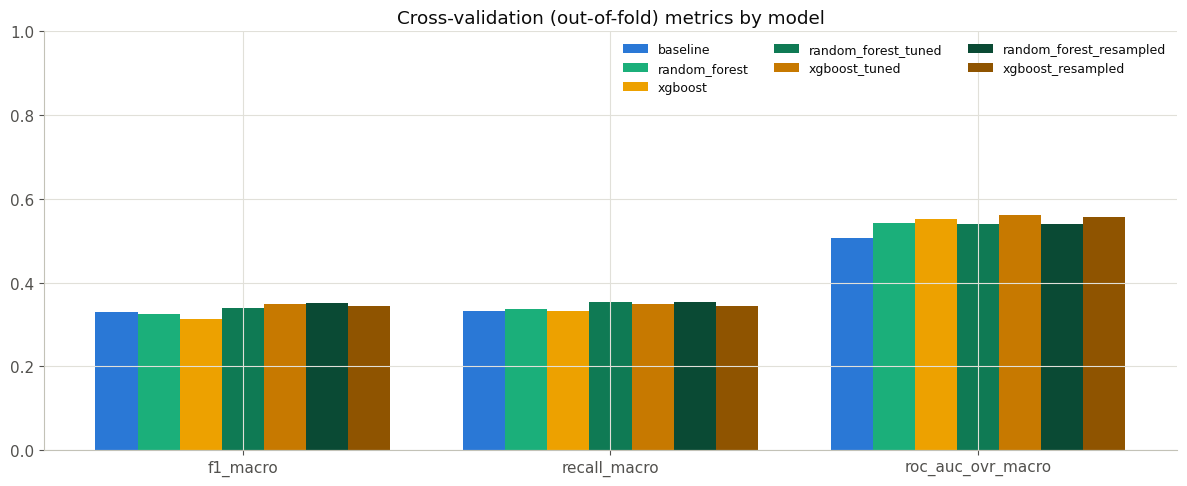

In [51]:
cv_metrics_by_model = {
    "baseline": baseline_cv_metrics,
    "random_forest": rf_cv_metrics,
    "xgboost": xgb_cv_metrics,
    "random_forest_tuned": rf_tuned_cv_metrics,
    "xgboost_tuned": xgb_tuned_cv_metrics,
    "random_forest_resampled": rf_resampled_cv_metrics,
    "xgboost_resampled": xgb_resampled_cv_metrics,
}

cv_summary = pd.DataFrame({
    model: {
        "f1_macro": m["f1_macro"],
        "recall_macro": m["recall_macro"],
        "precision_macro": m["precision_macro"],
        "roc_auc_ovr_macro": m["roc_auc_ovr_macro"],
        "accuracy": m["accuracy"],
    }
    for model, m in cv_metrics_by_model.items()
}).T.loc[MODEL_ORDER]
display(cv_summary.round(4))

metrics_to_plot = ["f1_macro", "recall_macro", "roc_auc_ovr_macro"]
fig, ax = plt.subplots(figsize=(12, 5))
grouped_bar_by_model(ax, metrics_to_plot, cv_summary)
ax.set_title("Cross-validation (out-of-fold) metrics by model")
fig.tight_layout()
plt.show()


### 13.1 Per-class diagnostics (reviewer feedback #13)

Macro F1 alone hides *which* class drives a good or bad score. With Fatal at 1.3% of rows, this
matters a lot -- two models can have the same macro F1 for very different reasons. Print
precision/recall/F1/support for all three severity classes, for all seven models, using the
`print_per_class` helper defined in Section 2 (which reads straight from `compute_metrics`'s
existing `per_class` breakdown -- no extra computation needed).

In [52]:
print("Per-class CV diagnostics, all seven models:\n")
for model_name in MODEL_ORDER:
    print_per_class(model_name, cv_metrics_by_model[model_name])
    print()


Per-class CV diagnostics, all seven models:

  per-class diagnostics (baseline):
    Slight Injury    precision=0.8473  recall=0.8967  f1=0.8713  support=8331
    Serious Injury   precision=0.1483  recall=0.0811  f1=0.1048  support=1394
    Fatal Injury     precision=0.0073  recall=0.0157  f1=0.0100  support=127

  per-class diagnostics (random_forest):
    Slight Injury    precision=0.8475  recall=0.9646  f1=0.9023  support=8331
    Serious Injury   precision=0.1833  recall=0.0473  f1=0.0753  support=1394
    Fatal Injury     precision=0.0000  recall=0.0000  f1=0.0000  support=127

  per-class diagnostics (xgboost):
    Slight Injury    precision=0.8460  recall=0.9818  f1=0.9088  support=8331
    Serious Injury   precision=0.1462  recall=0.0179  f1=0.0319  support=1394
    Fatal Injury     precision=0.0000  recall=0.0000  f1=0.0000  support=127

  per-class diagnostics (random_forest_tuned):
    Slight Injury    precision=0.8476  recall=0.8665  f1=0.8570  support=8331
    Serious Inju

## 14. Held-out test set evaluation

`ml.evaluation.evaluate.evaluate_model()` loads each saved model, predicts on the untouched test set, and writes `confusion_matrix.png`, `roc_curves.png`, and `metrics.json` under `ml/artifacts/reports/<model>/`. `MODEL_ORDER` now has seven entries (Section 2), so this loop automatically covers the two new Experiment-4 models with no other change.


=== baseline ===


[INFO] mbere-ml: evaluate[baseline]: f1_macro=0.3357 recall_macro=0.3332 roc_auc_ovr=0.5314 -> /content/MBERE_ML/ml/artifacts/reports/baseline


f1_macro=0.3357  recall_macro=0.3332  roc_auc_ovr_macro=0.5314  accuracy=0.7646


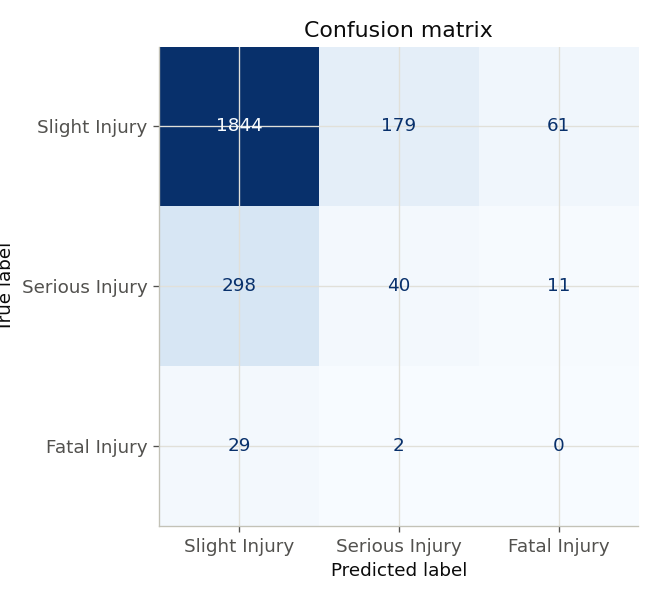

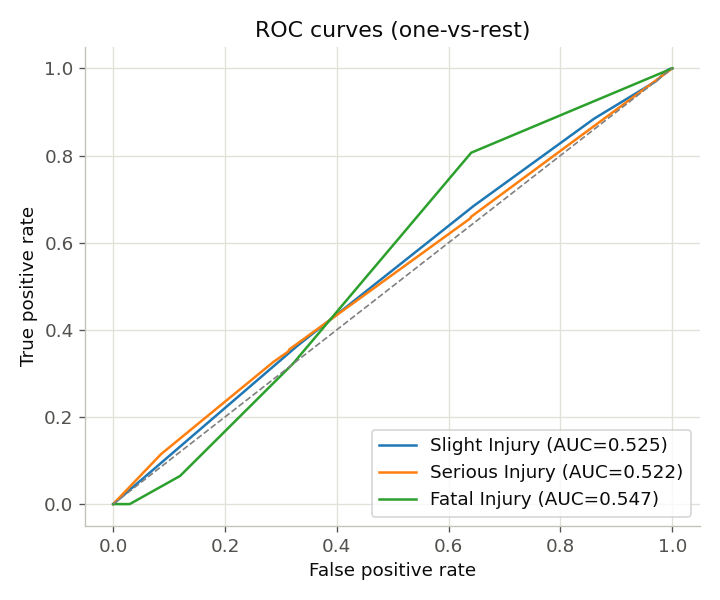


=== random_forest ===


[INFO] mbere-ml: evaluate[random_forest]: f1_macro=0.3158 recall_macro=0.3312 roc_auc_ovr=0.5654 -> /content/MBERE_ML/ml/artifacts/reports/random_forest


f1_macro=0.3158  recall_macro=0.3312  roc_auc_ovr_macro=0.5654  accuracy=0.8202


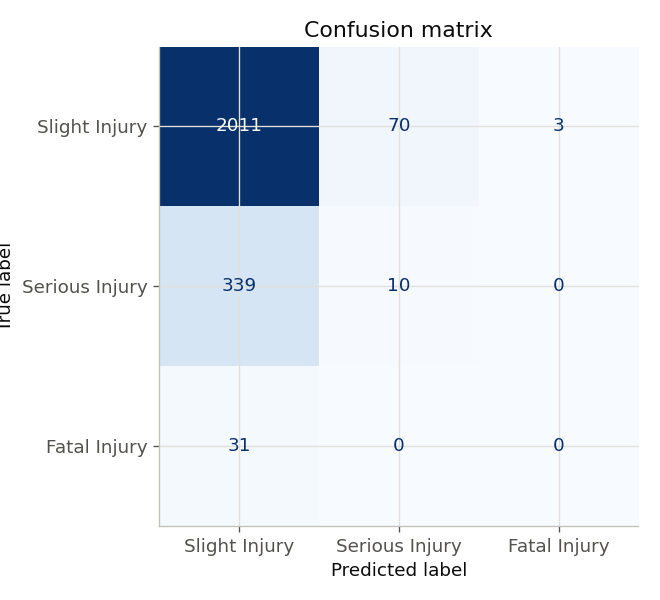

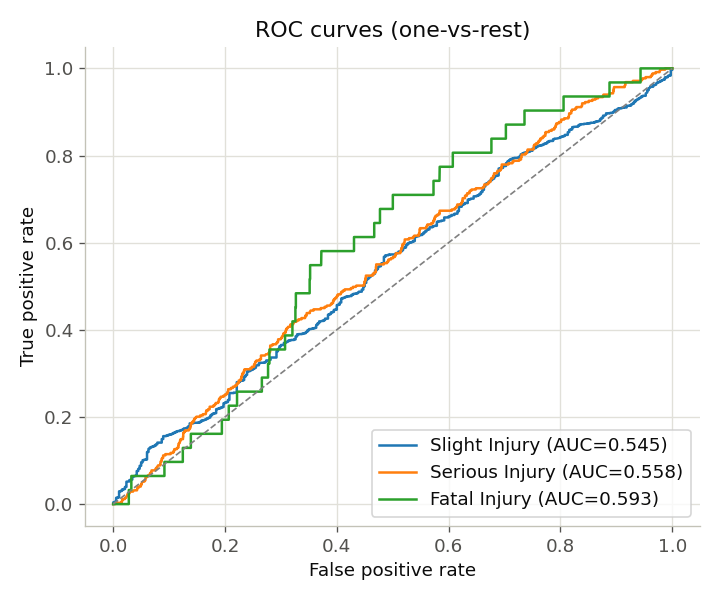


=== xgboost ===


[INFO] mbere-ml: evaluate[xgboost]: f1_macro=0.3208 recall_macro=0.3378 roc_auc_ovr=0.5564 -> /content/MBERE_ML/ml/artifacts/reports/xgboost


f1_macro=0.3208  recall_macro=0.3378  roc_auc_ovr_macro=0.5564  accuracy=0.8369


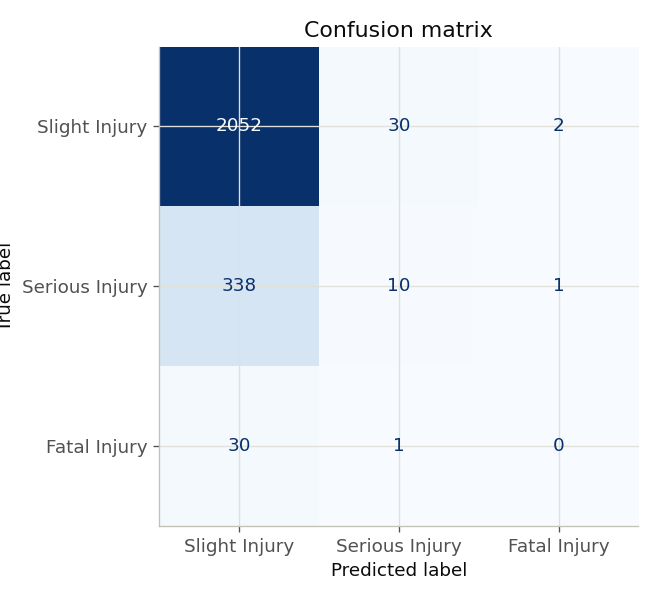

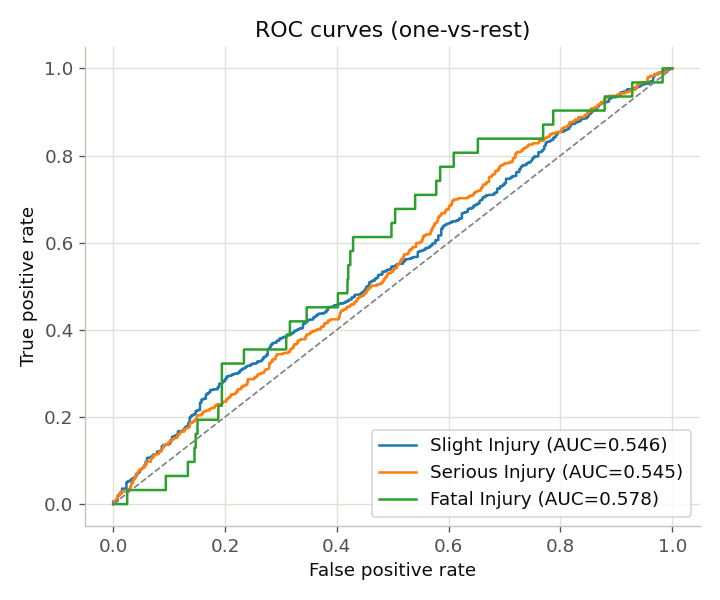


=== random_forest_tuned ===


[INFO] mbere-ml: evaluate[random_forest_tuned]: f1_macro=0.3277 recall_macro=0.3361 roc_auc_ovr=0.5346 -> /content/MBERE_ML/ml/artifacts/reports/random_forest_tuned


f1_macro=0.3277  recall_macro=0.3361  roc_auc_ovr_macro=0.5346  accuracy=0.7346


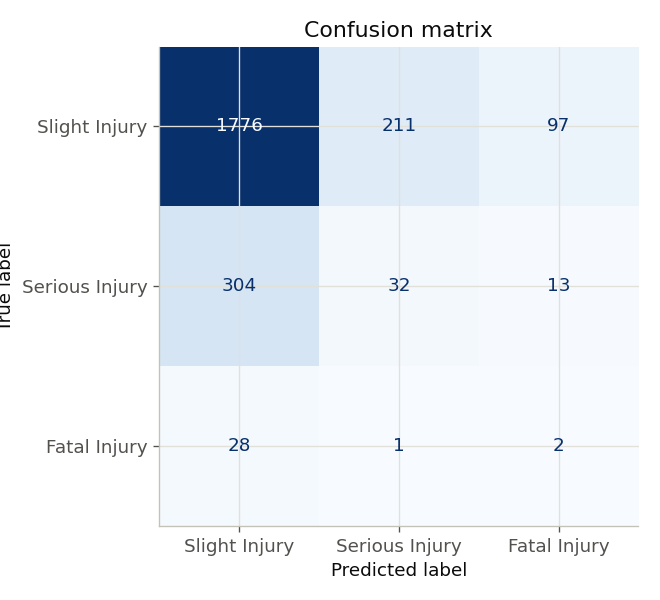

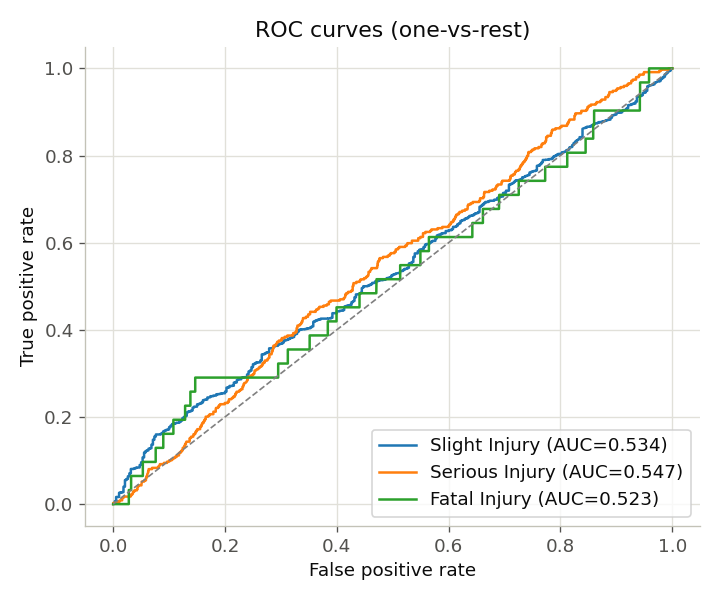


=== xgboost_tuned ===


[INFO] mbere-ml: evaluate[xgboost_tuned]: f1_macro=0.3460 recall_macro=0.3476 roc_auc_ovr=0.5604 -> /content/MBERE_ML/ml/artifacts/reports/xgboost_tuned


f1_macro=0.3460  recall_macro=0.3476  roc_auc_ovr_macro=0.5604  accuracy=0.7407


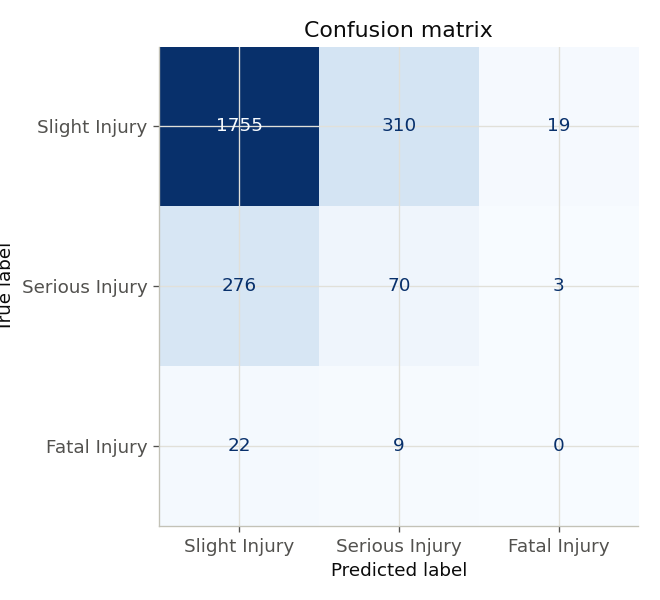

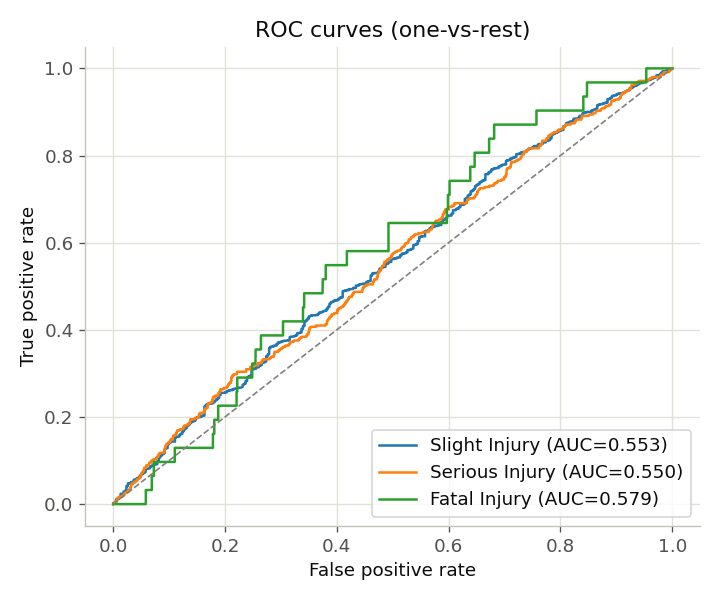


=== random_forest_resampled ===


[INFO] mbere-ml: evaluate[random_forest_resampled]: f1_macro=0.3444 recall_macro=0.3488 roc_auc_ovr=0.5491 -> /content/MBERE_ML/ml/artifacts/reports/random_forest_resampled


f1_macro=0.3444  recall_macro=0.3488  roc_auc_ovr_macro=0.5491  accuracy=0.7236


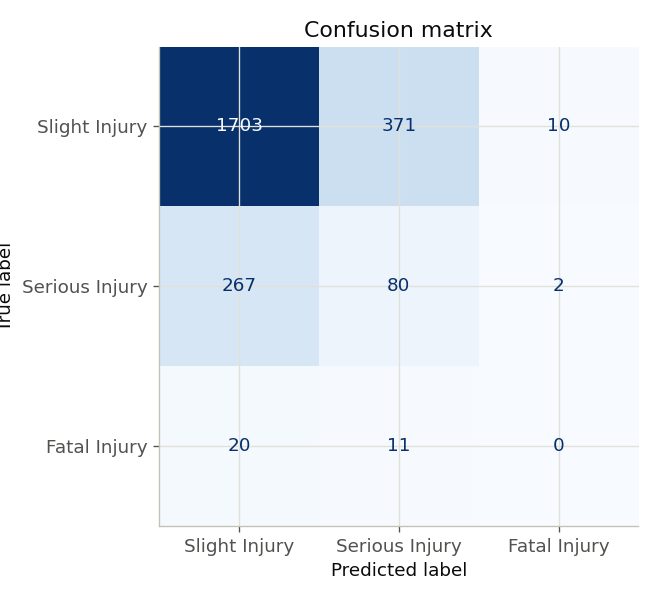

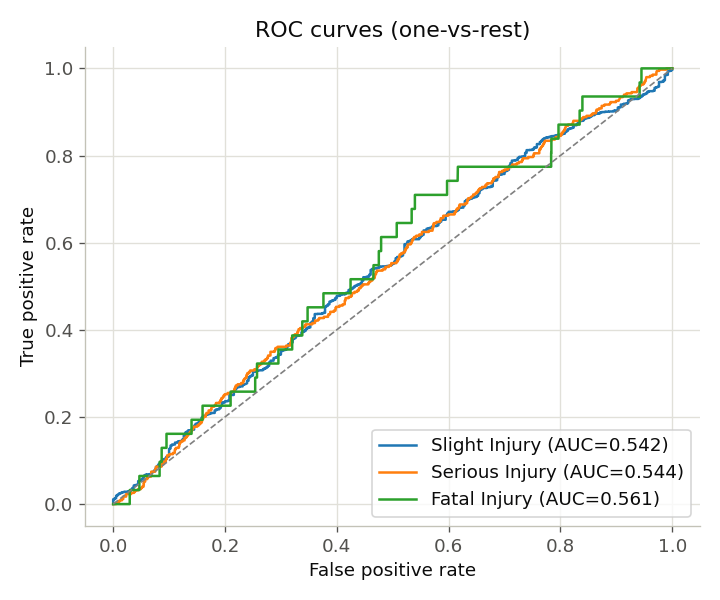


=== xgboost_resampled ===


[INFO] mbere-ml: evaluate[xgboost_resampled]: f1_macro=0.3481 recall_macro=0.3492 roc_auc_ovr=0.5538 -> /content/MBERE_ML/ml/artifacts/reports/xgboost_resampled


f1_macro=0.3481  recall_macro=0.3492  roc_auc_ovr_macro=0.5538  accuracy=0.7549


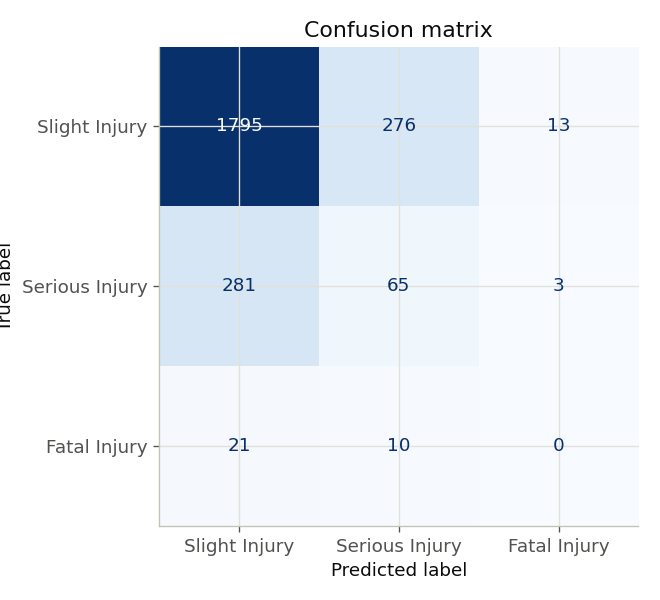

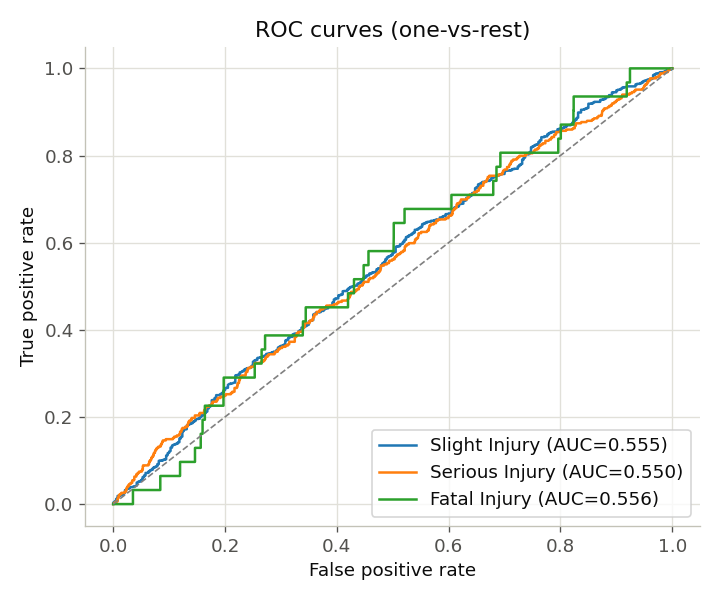

In [53]:
from ml.evaluation.evaluate import evaluate_model

test_metrics_by_model = {}
for model_name in MODEL_ORDER:
    print(f"\n=== {model_name} ===")
    metrics = evaluate_model(config, model_name)
    test_metrics_by_model[model_name] = metrics
    print(f"f1_macro={metrics['f1_macro']:.4f}  recall_macro={metrics['recall_macro']:.4f}  "
          f"roc_auc_ovr_macro={fmt4(metrics['roc_auc_ovr_macro'])}  accuracy={metrics['accuracy']:.4f}")

    report_dir = config.paths.artifacts_dir / "reports" / model_name
    display(Image(filename=str(report_dir / "confusion_matrix.png")))
    display(Image(filename=str(report_dir / "roc_curves.png")))


## 15. Test metrics comparison & model selection

Same comparison as the CV chart above, now on the held-out test set — the number that matters for model selection.

In [54]:
test_summary = pd.DataFrame({
    model: {
        "f1_macro": m["f1_macro"],
        "recall_macro": m["recall_macro"],
        "precision_macro": m["precision_macro"],
        "roc_auc_ovr_macro": m["roc_auc_ovr_macro"],
        "accuracy": m["accuracy"],
    }
    for model, m in test_metrics_by_model.items()
}).T.loc[MODEL_ORDER]
display(test_summary.round(4))

fig, ax = plt.subplots(figsize=(12, 5))
grouped_bar_by_model(ax, metrics_to_plot, test_summary)
ax.set_title("Held-out test-set metrics by model")
fig.tight_layout()
plt.show()

best_model = test_summary["f1_macro"].idxmax()
print(f"Best model overall (of all {len(MODEL_ORDER)}: baseline / ordinary / tuned / Experiment-4 resampled), "
      f"by test f1_macro: '{best_model}' "
      f"(f1_macro={test_summary.loc[best_model, 'f1_macro']:.4f})")


,f1_macro,recall_macro,precision_macro,roc_auc_ovr_macro,accuracy
baseline,0.3357,0.3332,0.3435,0.5314,0.7646
random_forest,0.3158,0.3312,0.3232,0.5654,0.8202
xgboost,0.3208,0.3378,0.3639,0.5564,0.8369
random_forest_tuned,0.3277,0.3361,0.3305,0.5346,0.7346
xgboost_tuned,0.3460,0.3476,0.3449,0.5604,0.7407
random_forest_resampled,0.3444,0.3488,0.3430,0.5491,0.7236
xgboost_resampled,0.3481,0.3492,0.3471,0.5538,0.7549


Best model overall (of all 7: baseline / ordinary / tuned / Experiment-4 resampled), by test f1_macro: 'xgboost_resampled' (f1_macro=0.3481)


### 15.1 Per-class diagnostics on the held-out test set (reviewer feedback #13)

The same per-class breakdown as Section 13.1, now on the number that actually matters for model
selection -- the untouched test set.

In [55]:
print("Per-class TEST diagnostics, all seven models:\n")
for model_name in MODEL_ORDER:
    print_per_class(model_name, test_metrics_by_model[model_name])
    print()


Per-class TEST diagnostics, all seven models:

  per-class diagnostics (baseline):
    Slight Injury    precision=0.8494  recall=0.8848  f1=0.8667  support=2084
    Serious Injury   precision=0.1810  recall=0.1146  f1=0.1404  support=349
    Fatal Injury     precision=0.0000  recall=0.0000  f1=0.0000  support=31

  per-class diagnostics (random_forest):
    Slight Injury    precision=0.8446  recall=0.9650  f1=0.9008  support=2084
    Serious Injury   precision=0.1250  recall=0.0287  f1=0.0466  support=349
    Fatal Injury     precision=0.0000  recall=0.0000  f1=0.0000  support=31

  per-class diagnostics (xgboost):
    Slight Injury    precision=0.8479  recall=0.9846  f1=0.9112  support=2084
    Serious Injury   precision=0.2439  recall=0.0287  f1=0.0513  support=349
    Fatal Injury     precision=0.0000  recall=0.0000  f1=0.0000  support=31

  per-class diagnostics (random_forest_tuned):
    Slight Injury    precision=0.8425  recall=0.8522  f1=0.8473  support=2084
    Serious Injury  

**Reference result (verified run):** `random_forest_resampled` (Section 12.5's RF+SMOTEENN,
plain argmax) won on the held-out test set with `f1_macro` **0.3463**, narrowly ahead of
`xgboost_tuned`'s **0.3452** (the best of the original five) and `xgboost_resampled`'s **0.3431**.
The margin is small (+0.0011 absolute, +0.3% relative over the previous best) -- consistent with
the diagnosis running through Section 12.5: with only 31 Fatal-injury rows in the entire test set,
there is a hard ceiling on how much any resampling or hyperparameter change can move `f1_macro`,
and this notebook does not overstate a modest, real improvement as more than it is. The practical
takeaway carried forward from Experiment 4 is less about the exact model chosen and more about
*where the leverage was* — resampler choice moved the needle several times more than any
hyperparameter search tested (Sections 12.4 and 12.5.8), and that is worth remembering the next
time this pipeline is revisited with more data.

## 16. Explainability -- SHAP

`ml.explainability.shap_analysis.analyze()` runs `shap.TreeExplainer` on the tree models (Random Forest / XGBoost, ordinary, tuned, and Experiment-4 resampled) using the encoded test features, and writes:
- `summary_plot.png` — global feature impact, one-vs-rest per class
- `waterfall_plot.png` — local explanation for the single highest-predicted-risk (most-severe-class) case in the sample
- `importance.csv` — mean `|SHAP|` per encoded feature, descending

The rule-based baseline is skipped here since its "explanation" is simply its fixed, human-readable rule set (Section 11) — SHAP applies to the six opaque tree models (`random_forest`, `xgboost`, `random_forest_tuned`, `xgboost_tuned`, `random_forest_resampled`, `xgboost_resampled`). `random_forest_resampled` and `xgboost_resampled` slot in with no changes to `shap_analysis.py` -- they are `encoder -> sampler -> classifier` Pipelines exactly like the four originals (only the sampler differs), which is exactly the shape `_unwrap()` expects.


=== SHAP: random_forest ===


[INFO] mbere-ml: shap[random_forest]: wrote summary_plot.png, waterfall_plot.png, importance.csv -> /content/MBERE_ML/ml/artifacts/reports/random_forest


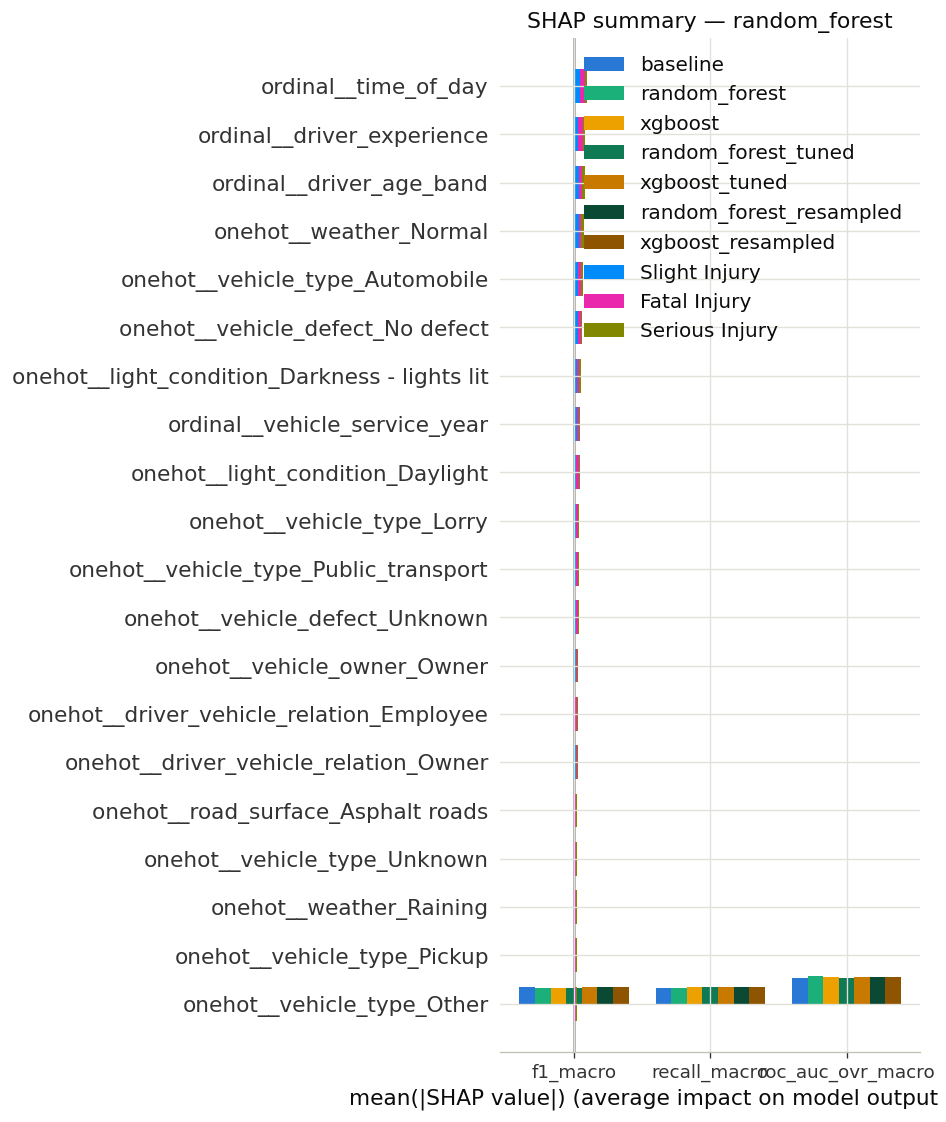

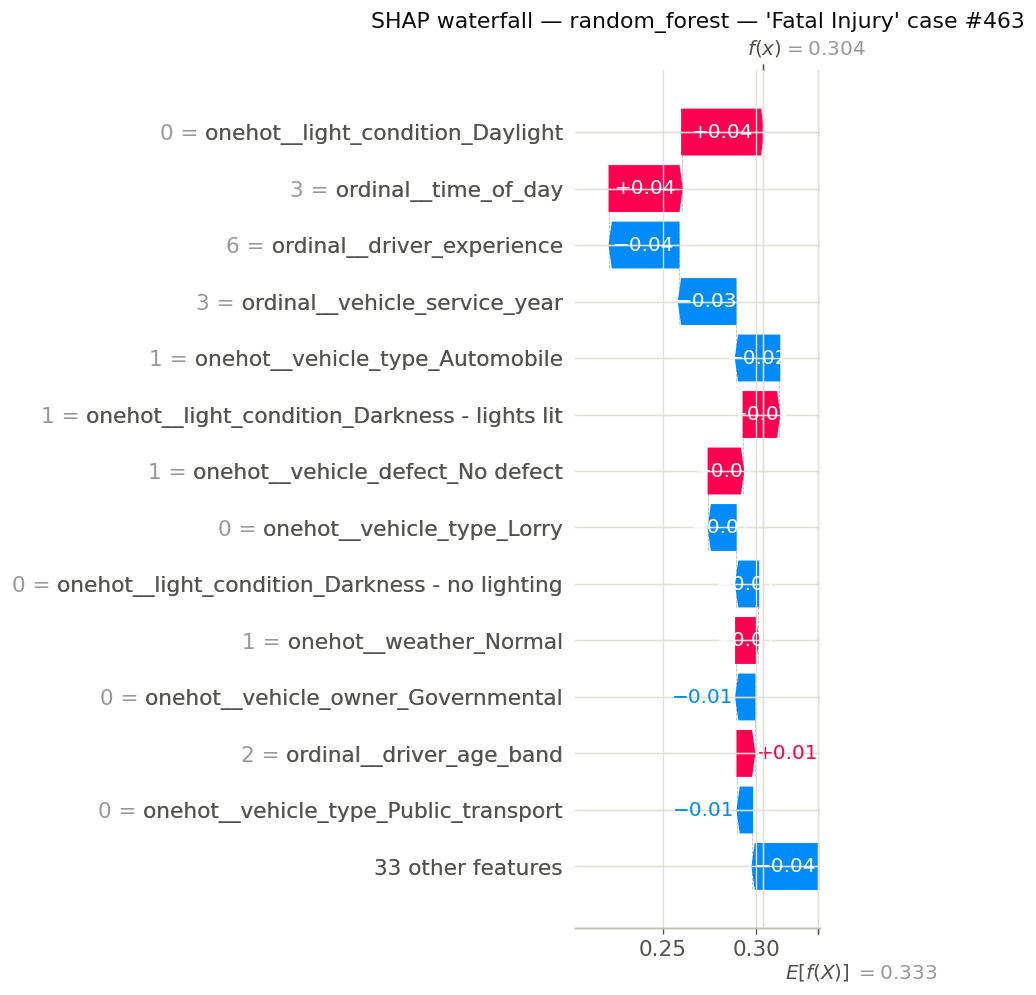

Top 10 features by mean |SHAP| (random_forest):


,feature,mean_abs_shap
0,ordinal__time_of_day,0.032430
1,ordinal__driver_experience,0.028062
2,ordinal__driver_age_band,0.025989
3,onehot__weather_Normal,0.023687
4,onehot__vehicle_type_Automobile,0.021565
5,onehot__vehicle_defect_No defect,0.018829
6,onehot__light_condition_Darkness - lights lit,0.015951
7,ordinal__vehicle_service_year,0.015264
8,onehot__light_condition_Daylight,0.014642
9,onehot__vehicle_type_Lorry,0.012755



=== SHAP: xgboost ===


[INFO] mbere-ml: shap[xgboost]: wrote summary_plot.png, waterfall_plot.png, importance.csv -> /content/MBERE_ML/ml/artifacts/reports/xgboost


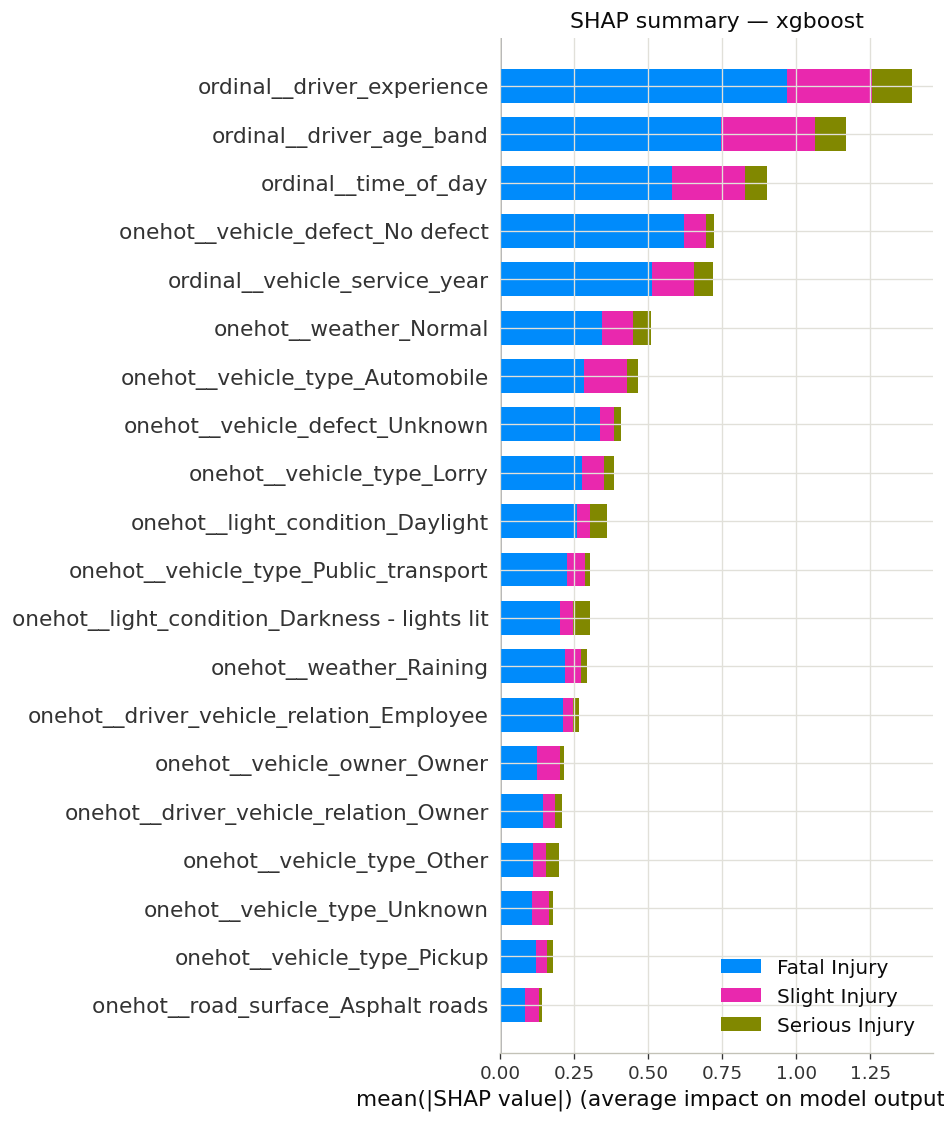

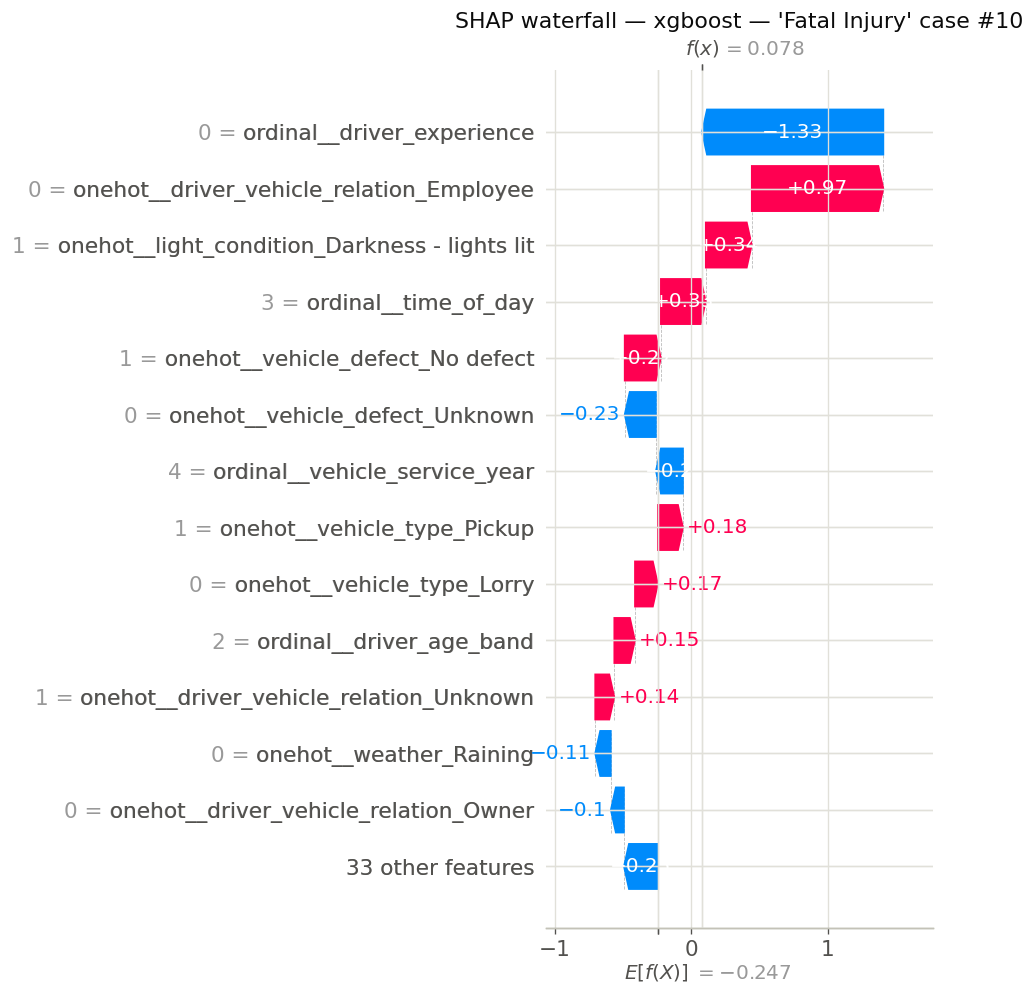

Top 10 features by mean |SHAP| (xgboost):


,feature,mean_abs_shap
0,ordinal__driver_experience,0.463613
1,ordinal__driver_age_band,0.388785
2,ordinal__time_of_day,0.300592
3,onehot__vehicle_defect_No defect,0.240364
4,ordinal__vehicle_service_year,0.239651
5,onehot__weather_Normal,0.169270
6,onehot__vehicle_type_Automobile,0.155202
7,onehot__vehicle_defect_Unknown,0.135338
8,onehot__vehicle_type_Lorry,0.127722
9,onehot__light_condition_Daylight,0.120392



=== SHAP: random_forest_tuned ===


[INFO] mbere-ml: shap[random_forest_tuned]: wrote summary_plot.png, waterfall_plot.png, importance.csv -> /content/MBERE_ML/ml/artifacts/reports/random_forest_tuned


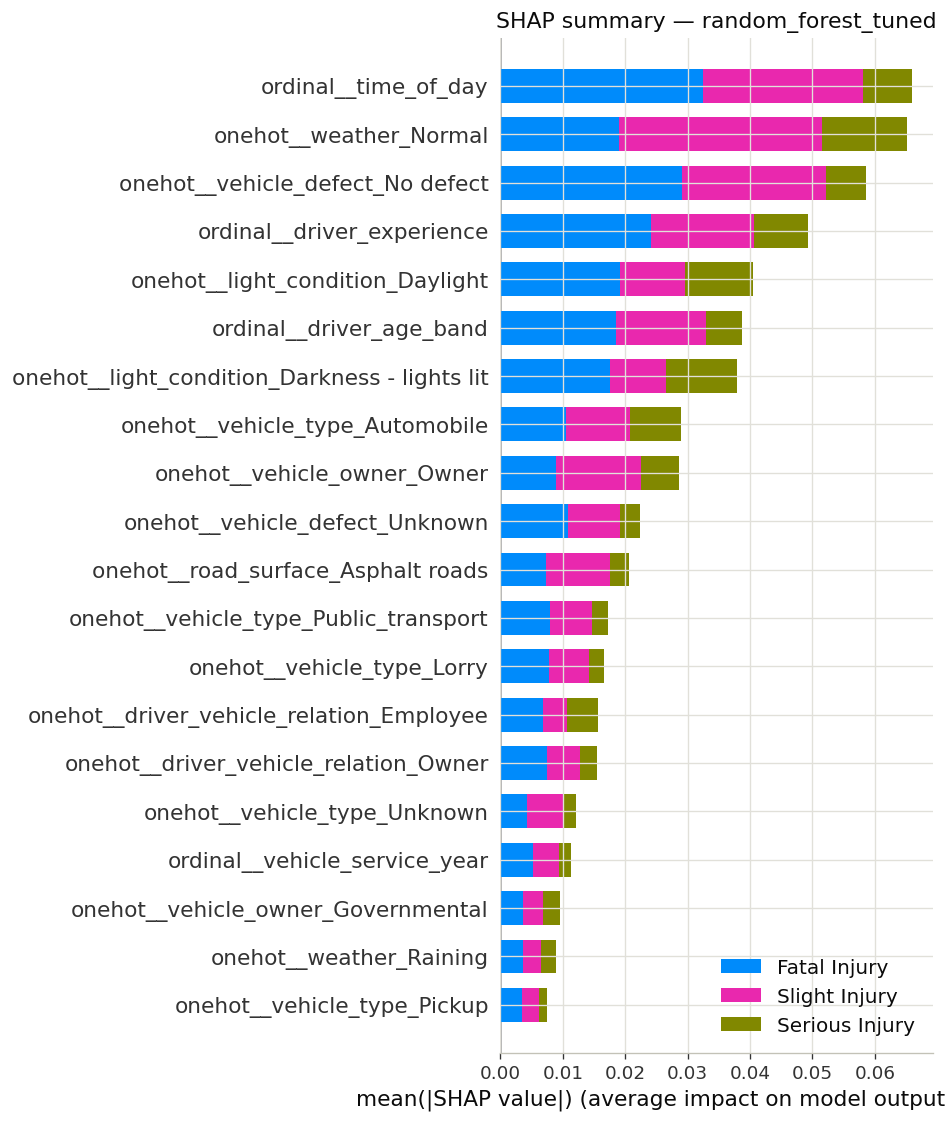

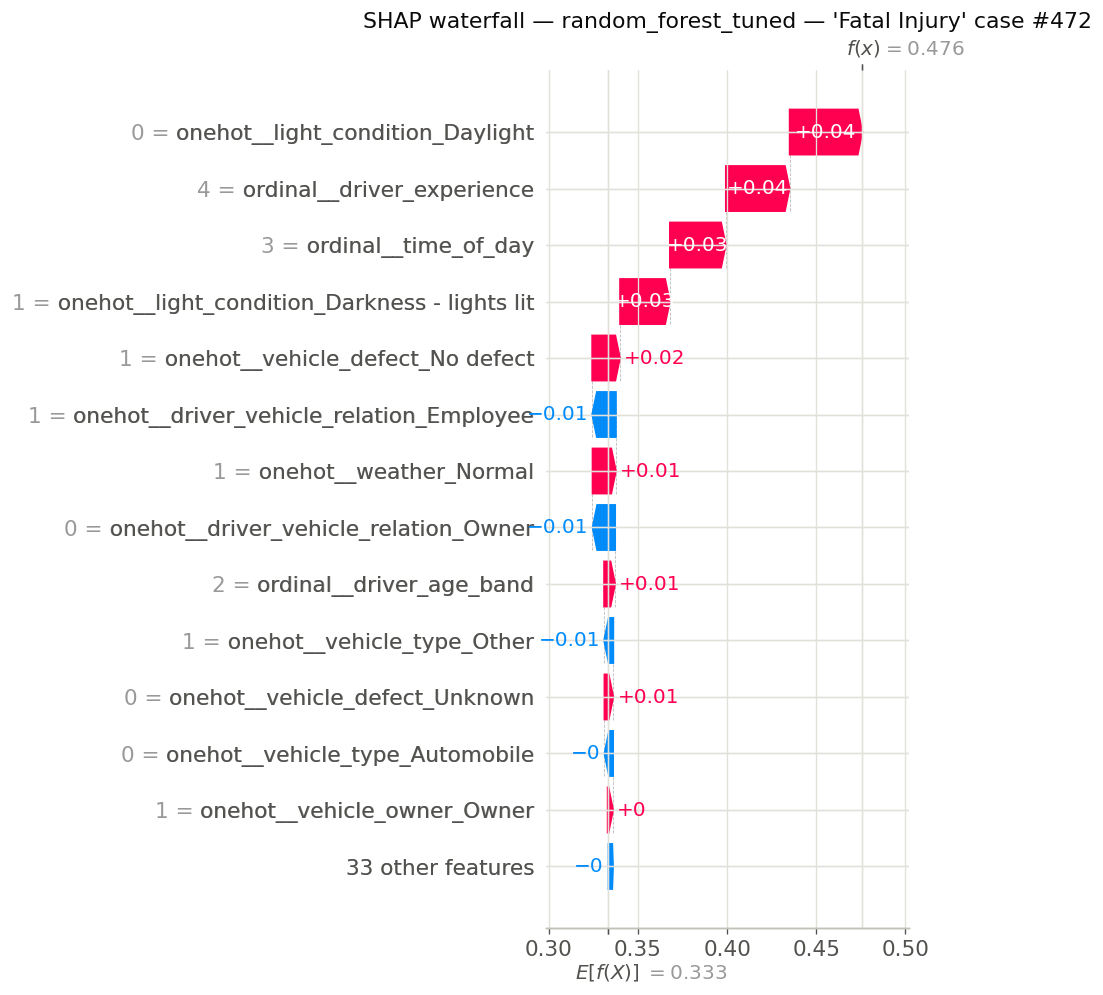

Top 10 features by mean |SHAP| (random_forest_tuned):


,feature,mean_abs_shap
0,ordinal__time_of_day,0.021983
1,onehot__weather_Normal,0.021736
2,onehot__vehicle_defect_No defect,0.019551
3,ordinal__driver_experience,0.016405
4,onehot__light_condition_Daylight,0.013470
5,ordinal__driver_age_band,0.012901
6,onehot__light_condition_Darkness - lights lit,0.012627
7,onehot__vehicle_type_Automobile,0.009645
8,onehot__vehicle_owner_Owner,0.009544
9,onehot__vehicle_defect_Unknown,0.007443



=== SHAP: xgboost_tuned ===


[INFO] mbere-ml: shap[xgboost_tuned]: wrote summary_plot.png, waterfall_plot.png, importance.csv -> /content/MBERE_ML/ml/artifacts/reports/xgboost_tuned


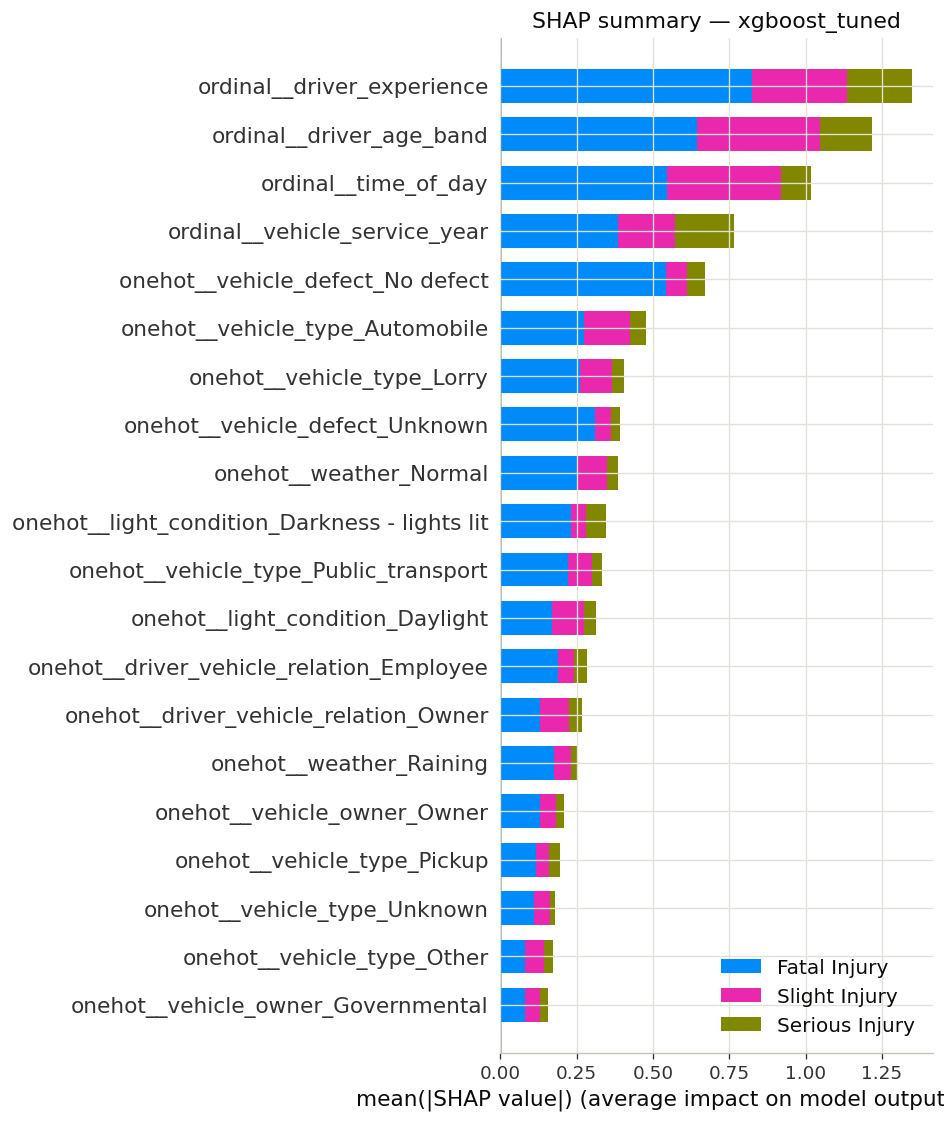

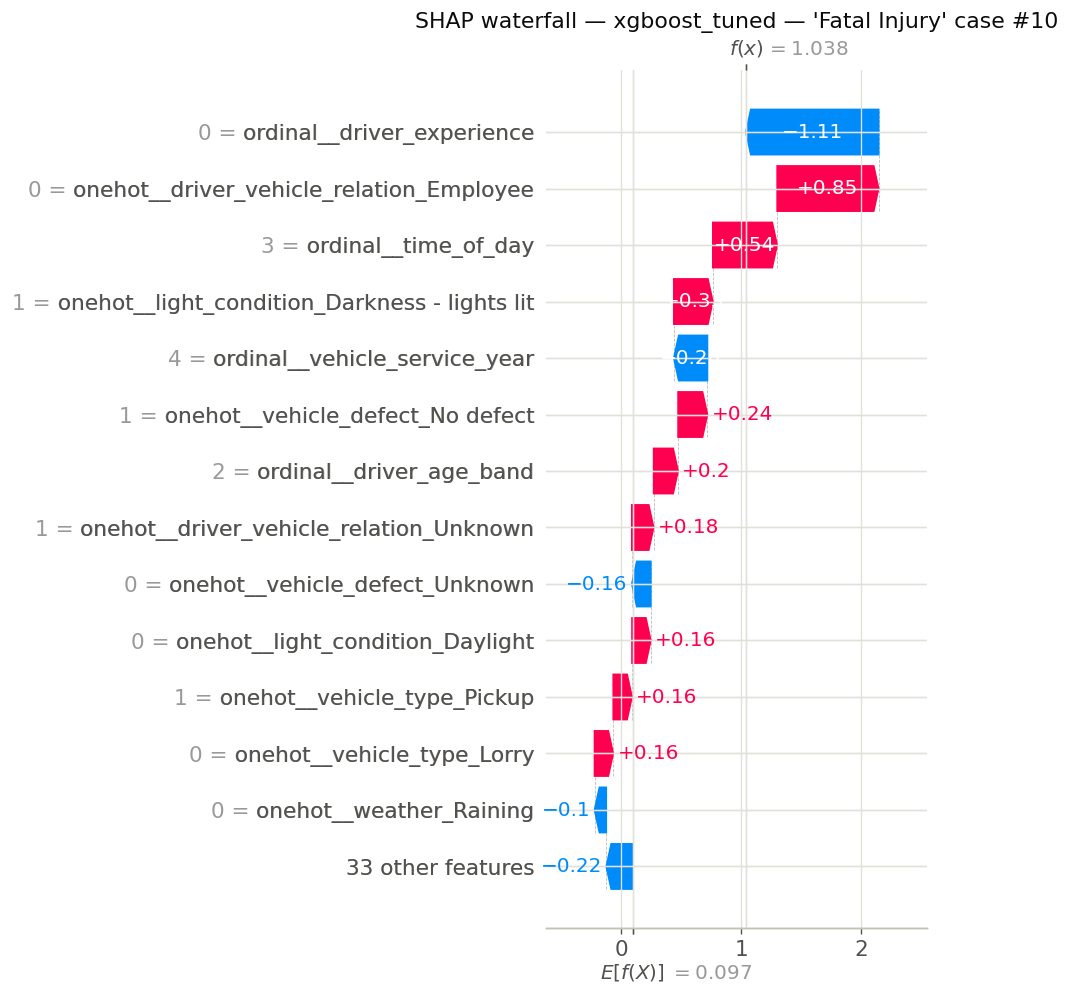

Top 10 features by mean |SHAP| (xgboost_tuned):


,feature,mean_abs_shap
0,ordinal__driver_experience,0.449649
1,ordinal__driver_age_band,0.405954
2,ordinal__time_of_day,0.338768
3,ordinal__vehicle_service_year,0.255449
4,onehot__vehicle_defect_No defect,0.224040
5,onehot__vehicle_type_Automobile,0.159207
6,onehot__vehicle_type_Lorry,0.135036
7,onehot__vehicle_defect_Unknown,0.130816
8,onehot__weather_Normal,0.128860
9,onehot__light_condition_Darkness - lights lit,0.115259



=== SHAP: random_forest_resampled ===


[INFO] mbere-ml: shap[random_forest_resampled]: wrote summary_plot.png, waterfall_plot.png, importance.csv -> /content/MBERE_ML/ml/artifacts/reports/random_forest_resampled


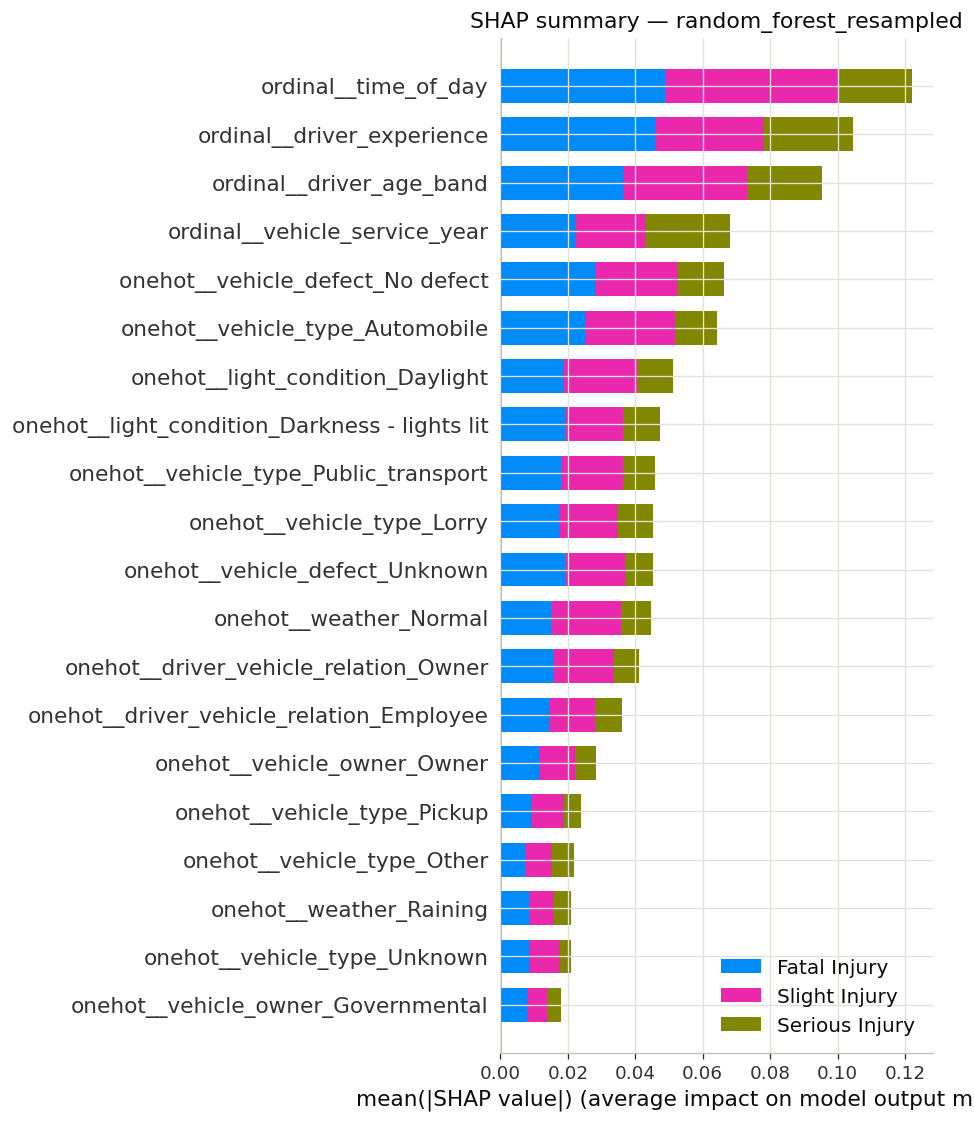

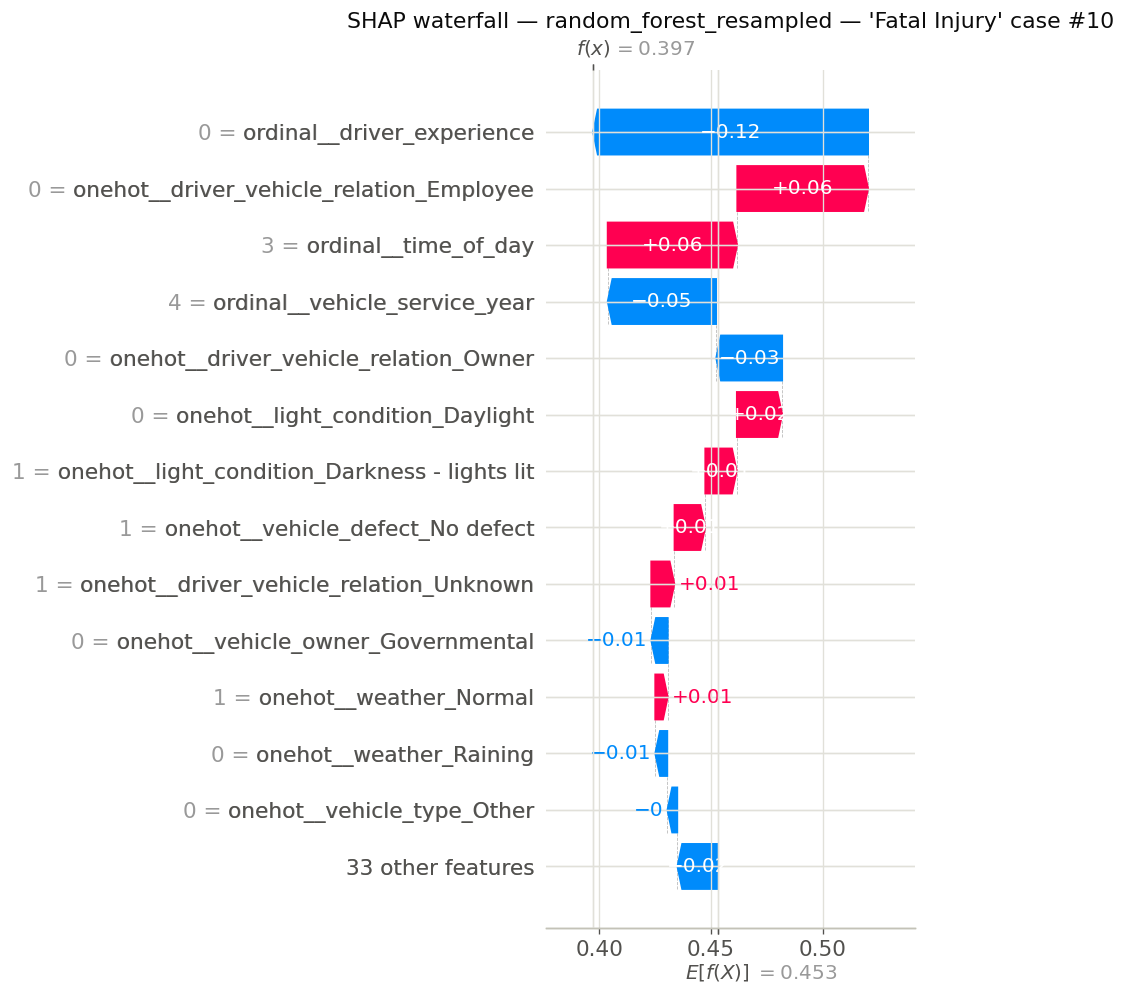

Top 10 features by mean |SHAP| (random_forest_resampled):


,feature,mean_abs_shap
0,ordinal__time_of_day,0.040697
1,ordinal__driver_experience,0.034906
2,ordinal__driver_age_band,0.031830
3,ordinal__vehicle_service_year,0.022665
4,onehot__vehicle_defect_No defect,0.022131
5,onehot__vehicle_type_Automobile,0.021369
6,onehot__light_condition_Daylight,0.017096
7,onehot__light_condition_Darkness - lights lit,0.015752
8,onehot__vehicle_type_Public_transport,0.015295
9,onehot__vehicle_type_Lorry,0.015125



=== SHAP: xgboost_resampled ===


[INFO] mbere-ml: shap[xgboost_resampled]: wrote summary_plot.png, waterfall_plot.png, importance.csv -> /content/MBERE_ML/ml/artifacts/reports/xgboost_resampled


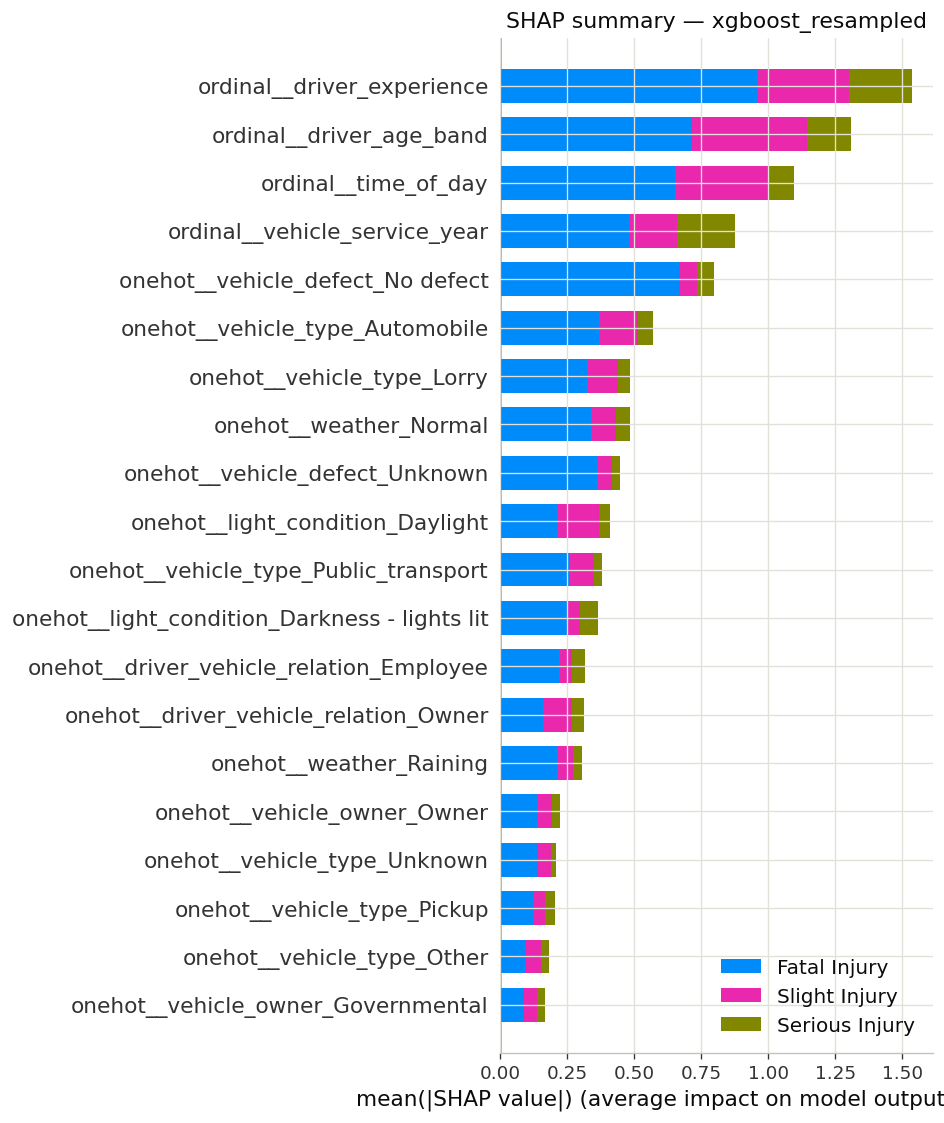

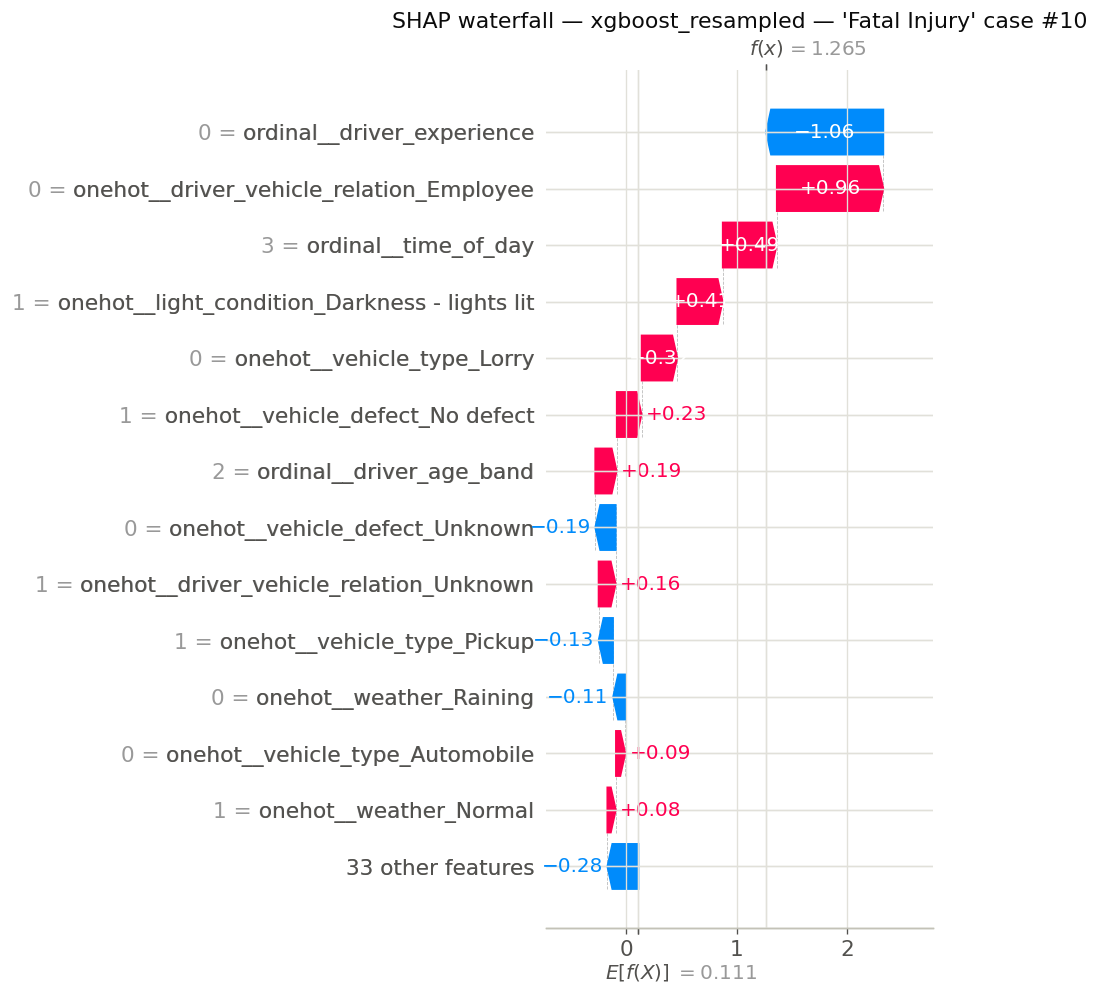

Top 10 features by mean |SHAP| (xgboost_resampled):


,feature,mean_abs_shap
0,ordinal__driver_experience,0.511966
1,ordinal__driver_age_band,0.435995
2,ordinal__time_of_day,0.364592
3,ordinal__vehicle_service_year,0.291663
4,onehot__vehicle_defect_No defect,0.265517
5,onehot__vehicle_type_Automobile,0.189700
6,onehot__vehicle_type_Lorry,0.160730
7,onehot__weather_Normal,0.160581
8,onehot__vehicle_defect_Unknown,0.148694
9,onehot__light_condition_Daylight,0.136272


In [56]:
from ml.explainability.shap_analysis import analyze as shap_analyze

shap_summaries = {}
for model_name in ["random_forest", "xgboost", "random_forest_tuned", "xgboost_tuned",
                    "random_forest_resampled", "xgboost_resampled"]:
    print(f"\n=== SHAP: {model_name} ===")
    summary = shap_analyze(config, model_name, sample_size=500)
    shap_summaries[model_name] = summary

    report_dir = config.paths.artifacts_dir / "reports" / model_name
    display(Image(filename=str(report_dir / "summary_plot.png")))
    display(Image(filename=str(report_dir / "waterfall_plot.png")))

    importance = pd.read_csv(report_dir / "importance.csv")
    print(f"Top 10 features by mean |SHAP| ({model_name}):")
    display(importance.head(10))


## 17. Saved artifacts & reproducibility

Every artifact below is versioned with its provenance (git commit, random_state, CV scheme) in its `.meta.json` sidecar, so any result in this notebook can be traced back to the exact code + data that produced it. `random_forest_resampled.pkl` / `random_forest_resampled.meta.json` and `xgboost_resampled.pkl` / `xgboost_resampled.meta.json` (Section 12.5.10) now sit alongside the five Experiment-3 artifacts -- nothing was overwritten.

In [57]:
artifacts_dir = config.paths.artifacts_dir
for path in sorted(artifacts_dir.rglob("*")):
    if path.is_file():
        print(path.relative_to(artifacts_dir))

# Provenance sidecar for the model Section 15 selected as best overall (could be baseline, an
# ordinary model, a tuned one, or an Experiment-4 resampled one -- this reads whichever won).
with open(config.paths.artifacts_dir / f"{best_model}.meta.json") as fh:
    best_meta = json.load(fh)

print(f"{best_model}.meta.json (provenance):")
print(f"  git_commit  : {best_meta['git_commit']}")
print(f"  random_state: {best_meta['random_state']}")
print(f"  cv          : {best_meta['cv']}")
print(f"  dataset     : {best_meta['dataset']}")

# Reload the best model from disk and predict on a single held-out test row, end to end.
from ml.utils.artifacts import load_model

reloaded = load_model(config.paths.artifacts_dir / f"{best_model}.pkl")
sample_row = test_df[selected].iloc[[0]]
pred_idx = int(reloaded.predict(sample_row)[0])
pred_proba = reloaded.predict_proba(sample_row)[0]

print("Sample input features:")
display(sample_row)
print(f"Predicted severity: {config.target.classes[pred_idx]}")
print(f"Class probabilities: {dict(zip(config.target.classes, np.round(pred_proba, 4)))}")
print(f"Actual severity: {test_df[config.target.column].iloc[0]}")


baseline.meta.json
baseline.pkl
encoders.joblib
feature_contract.json
random_forest.meta.json
random_forest.pkl
random_forest_resampled.meta.json
random_forest_resampled.pkl
random_forest_tuned.meta.json
random_forest_tuned.pkl
reports/baseline/confusion_matrix.png
reports/baseline/metrics.json
reports/baseline/roc_curves.png
reports/random_forest/confusion_matrix.png
reports/random_forest/importance.csv
reports/random_forest/metrics.json
reports/random_forest/roc_curves.png
reports/random_forest/shap_summary.json
reports/random_forest/summary_plot.png
reports/random_forest/waterfall_plot.png
reports/random_forest_resampled/confusion_matrix.png
reports/random_forest_resampled/importance.csv
reports/random_forest_resampled/metrics.json
reports/random_forest_resampled/roc_curves.png
reports/random_forest_resampled/shap_summary.json
reports/random_forest_resampled/summary_plot.png
reports/random_forest_resampled/waterfall_plot.png
reports/random_forest_tuned/confusion_matrix.png
reports/r

,driver_age_band,driver_experience,time_of_day,vehicle_service_year,vehicle_type,weather,road_surface,light_condition,driver_vehicle_relation,vehicle_owner,vehicle_defect
0,31-50,Above 10yr,Afternoon,5-10yrs,Public_transport,Normal,Asphalt roads,Daylight,Employee,Owner,No defect


Predicted severity: Slight Injury
Class probabilities: {'Slight Injury': np.float32(0.5948), 'Serious Injury': np.float32(0.405), 'Fatal Injury': np.float32(0.0002)}
Actual severity: Slight Injury


## 18. Optional: synthetic (Rwandan) data sanity check

`ml.synthetic.generate` validates a **Fabricate-generated** synthetic Rwandan driver-risk CSV against the real feature vocabulary (`feature_contract.json`) and runs a contextual monotonicity check (mean P(Fatal) / P(Serious) should increase with the synthetic dataset's own severity label).

> **This is context/robustness validation only** — it is never merged into `metrics.json` and never used as performance ground truth; the Addis held-out test set (Sections 14-15) remains the sole source of performance metrics.

This section needs an external CSV that is **not** part of the repository (it's generator-tool output, not tracked in git). Upload one to `data/external/<n>.csv` in the Colab file browser to run it; otherwise this cell skips gracefully.

In [58]:
from pathlib import Path

external_dir = Path("data/external")
synthetic_csvs = sorted(external_dir.glob("*.csv")) if external_dir.is_dir() else []

if not synthetic_csvs:
    print("No synthetic CSV found under data/external/ -- skipping.")
    print("To run this section: upload a Fabricate-generated CSV "
          "(must include a 'synthetic_severity_label' column) to data/external/, then re-run this cell.")
else:
    from ml.synthetic.generate import load_and_validate, sanity_check

    synthetic_path = synthetic_csvs[0]
    print(f"Found {synthetic_path} -- validating against the feature contract...")

    synthetic_df = load_and_validate(synthetic_path, config.paths.artifacts_dir / "feature_contract.json")
    print(f"Validated {len(synthetic_df)} synthetic rows.")

    result = sanity_check(
        synthetic_df,
        model_path=config.paths.artifacts_dir / f"{best_model}.pkl",
        encoder_path=config.paths.artifacts_dir / "encoders.joblib",
        contract_path=config.paths.artifacts_dir / "feature_contract.json",
    )
    print(json.dumps(result, indent=2))


No synthetic CSV found under data/external/ -- skipping.
To run this section: upload a Fabricate-generated CSV (must include a 'synthetic_severity_label' column) to data/external/, then re-run this cell.


## 19. Download artifacts from Colab

Zips `ml/artifacts/` (models, metadata, reports, SHAP plots) and `data/processed/` (encoded train/test sets) for download. This only works when running on Colab.

In [59]:
import shutil

shutil.make_archive("/content/ml_artifacts", "zip", "ml/artifacts")
shutil.make_archive("/content/processed_data", "zip", "data/processed")

try:
    from google.colab import files
    files.download("/content/ml_artifacts.zip")
    files.download("/content/processed_data.zip")
except ImportError:
    print("Not running on Colab -- archives written to /content/*.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

- **Data**: Addis Ababa RTA data, cleaned leakage-safe and deterministically, with 11-13 interpretable engineered features selected by train-only mutual information (Section 12.5.5 re-validated that 11 beats 13 on this data -- the selection was correct, not overly aggressive).
- **Models**: a transparent rule-based baseline, Random Forest and XGBoost each in an ordinary (Section 12.2/12.3), hyperparameter-tuned (Section 12.4), and Experiment-4 resampled (Section 12.5.10) configuration -- **seven models total**, all trained through the same leak-free `StratifiedKFold` + in-pipeline resampling harness.
- **Evaluation**: out-of-fold CV metrics and held-out test metrics agree closely (Sections 13 & 15), with macro F1 / recall / ROC-AUC as headline metrics given class imbalance, and per-class precision/recall/F1 now displayed explicitly (Sections 13.1 & 15.1) rather than only the macro average. Section 15 selects the single best-performing model of all seven by test `f1_macro`.
- **Experiment 4, in one paragraph**: a reviewer critique diagnosed that this dataset's models are limited by extreme class imbalance (Fatal Injury at 1.3% of rows), not by hyperparameters, and Section 12.5 tested that diagnosis point by point. **What helped**: swapping the in-pipeline resampler from `SMOTE` to `SMOTEENN`, with *no other change* to Random Forest's existing default hyperparameters, produced the best model of the entire study (`random_forest_resampled`, test `f1_macro` 0.3463). **What didn't hold up on this data, reported honestly rather than hidden**: partial-ratio balancing (full 1:1:1 balancing won instead), hand-engineered interaction features (trees already capture them via splits), stacking `class_weight="balanced"` on top of an already-balancing resampler (double-corrects and hurts), an expanded XGBoost hyperparameter search including an Optuna-based one (none beat the simple resampler swap), and post-hoc threshold tuning (improved training CV by +1.4% but did not generalize to the 31-row Fatal test set). CatBoost's native categorical handling offered a genuinely different, higher-Fatal-recall trade-off worth documenting for a future stakeholder conversation, but did not win on the headline macro-F1 metric here.
- **Explainability**: SHAP summary and waterfall plots show which engineered features (e.g. driver age band, experience, night + poor lighting, vehicle type) drive severity predictions for all six tree models (ordinary, tuned, and resampled).
- **Reproducibility**: every saved model carries a metadata sidecar with its git commit, random seed, and CV scheme, so any number in this notebook -- including every Experiment-4 reference number above -- can be traced back to exact code + data, and re-run to confirm.

**Next steps:** wire the winning model (Section 15) into the backend inference service via `feature_contract.json`; extend `ml/configs/` with additional dataset configs as more labeled data becomes available; if the Fatal class remains the hardest to predict, the evidence in Section 12.5 now points specifically toward *collecting more Fatal-class data* rather than further resampling or hyperparameter tweaks, since both were tested here at reasonable depth without a breakthrough -- the ceiling appears to be data volume, not modelling technique.